# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision  tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 21.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.0 MB/s eta 0:00:00


In [2]:
# Cell 1: Install required libs (run in a cell)
!pip install lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds torchmetrics

# Config

In [30]:
config = {
    "algo": "FOND",
    "dataset": ["VLCS"],
    "test_set_id": 0,
    "data_dir": {"VLCS": r"/kaggle/input/datasets/iamjanvijay/vlcsdataset"},
    "log_dir": r"/kaggle/working/fond_dada_lodo_vlcs",
    "n_epochs": 5001,
    "checkpoint_freq": 300,
    "holdout_fraction": 0.2,
    "model_checkpoint": {"metric": "val/acc", "maximize": True},
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,
    "num_workers": 4,
    "overlap": "high",
    "num_classes": None,
    "num_domain_linked_classes": None,
    "auto_augment": False,
    "teacher_paths": {},
}


# Imports

In [4]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset





# SRC

## Domain Creation

In [5]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## Hparams

In [6]:
"""
Hyper-parameter registry
"""


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.

    _hparam("data_augmentation", True, lambda r: True)
    _hparam("resnet18", True, lambda r: True)
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions. Each block of code below
    # corresponds to exactly one algorithm.

    if (
        algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-and-algorithm-specific hparam definitions. Each block of code
    # below corresponds to exactly one hparam. Avoid nested conditionals.

    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}


## Misc

In [10]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1
    
    network.train()
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes
    
    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)
            
            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()
            
            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)
    
    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy
    
    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])
    
    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)
    
    other_acc = correct / total
    
    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [9]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""
    
    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV
        
        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}
            
        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value
        
        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()
            
        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return
            
        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write
        
    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)
        
        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)
            
    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""
    
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" 
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")
        
    def close(self):
        pass


# DADA

In [11]:
import os, json, random, logging
import numpy as np
import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [12]:
class DiffGaussianNoise(nn.Module):
    def __init__(self, std=0.05):
        super().__init__()
        self.std = std

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.randn_like(x) * self.std
        return x + noise


class DiffColorJitter(nn.Module):
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        super().__init__()
        self.b = brightness
        self.c = contrast
        self.s = saturation
        self.h = hue

    def forward(self, img):
        if not self.training:
            return img

        if self.b > 0:
            img = img * (1 + torch.randn(1).item() * self.b)

        if self.c > 0:
            mean = img.mean(dim=[2,3], keepdim=True)
            img = (img - mean) * (1 + torch.randn(1).item() * self.c) + mean

        if self.s > 0:
            gray = img.mean(dim=1, keepdim=True)
            img = img + (img - gray) * (1 + torch.randn(1).item() * self.s)

        if self.h > 0:
            theta = torch.randn(1).item() * self.h
            u, w = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
            rot = torch.tensor([[u, -w, 0],[w, u, 0],[0, 0, 1]], device=img.device)
            img = torch.einsum('bchw,dc->bdhw', img, rot)

        return img


class DiffHSB(nn.Module):
    def __init__(self, hue=0.05, saturation=0.2, brightness=0.2):
        super().__init__()
        self.h = hue
        self.s = saturation
        self.b = brightness

    def forward(self, x):
        if not self.training:
            return x

        x = x * (1 + torch.randn(1).item() * self.h)
        x = torch.clamp(x, 0, 1)
        return x


class DiffAugment(nn.Module):
    def __init__(self):
        super().__init__()
        self.color = DiffColorJitter()
        self.hsb = DiffHSB()
        self.gauss = DiffGaussianNoise(0.03)

    def forward(self, x):
        x = self.color(x)
        x = self.hsb(x)
        x = self.gauss(x)
        return torch.clamp(x, 0, 1)


In [13]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, diff_aug):
        self.base = base_dataset
        self.diff_aug = diff_aug

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if isinstance(x, torch.Tensor):
            x = self.diff_aug(x.unsqueeze(0)).squeeze(0)
        return x, y



In [14]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

diff_augment = DiffAugment().to(device)



In [15]:
def load_dataset(name, data_dir, domains, split, auto_augment):

    if name == "VLCS":
        dataset = VLCS(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    elif name == "PACS":
        dataset = PACS(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    elif name == "OfficeHome":
        dataset = OfficeHome(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    else:
        raise ValueError("Unknown dataset")

    #  DiffAugment ONLY for TRAIN
    if split == "train" and auto_augment:
        dataset = AugmentedDataset(dataset, diff_augment)

    return dataset



# Dataset

## Base

In [16]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

DATASETS2 = [
    # Debug
    "Debug28",
    "Debug224",
    # Small images
    "ColoredMNIST",
    "RotatedMNIST",
    # Big images
    "VLCS",
    "PACS",
    "OfficeHome",
    "TerraIncognita",
    "DomainNet",
    "SVIRO",
    # WILDS datasets
    "WILDSCamelyon",
    "WILDSFMoW",
    # Spawrious datasets
    "SpawriousO2O_easy",
    "SpawriousO2O_medium",
    "SpawriousO2O_hard",
    "SpawriousM2M_easy",
    "SpawriousM2M_medium",
    "SpawriousM2M_hard",
]

# OVERLAP_TYPES = ["none", "low", "mid", "high", "full", "0", "33", "66", "100"]
SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]


def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))

    random_state = np.random.RandomState(seed)

    # choose non overlapping classes
    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]

    # add to queue
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robing distribution of classes
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    # assert overlapping classes
    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)

    assert C_oc == list(np.where(overlap > 1)[0])

    # output
    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)

    return domain_classes


class DomainBedImageFolder(ImageFolder):
    """
    Custom class to allow class filtering
    """

    def __init__(
        self,
        root: str,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        remove_classes: List[int] = [],
        allowed_classes: List[int] = [],
        is_test_env: Optional[bool] = None,
        env_name: Optional[str] = None,
    ):
        super().__init__(root, transform, target_transform)

        # Remove specified classes
        old_samples = self.samples
        self.samples = []
        self.targets = []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name
        for sample in old_samples:
            _, target = sample

            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self) -> int:
        return len(self.samples)

    def __str__(self):
        return (
            f"{self.env_name}: is_test_env={self.is_test_env}, allowed_classes={self.allowed_classes},"
            f" list(set(self.targets))={self.classes}, num_samples={len(self)}"
        )


def get_overlapping_classes(
    class_split: List[List[int]], num_classes: int
) -> List[int]:
    """
    Return the classes in multiple domains.
    """
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)

    overlapping_classes = list(np.where(overlap > 1)[0])

    return overlapping_classes


def get_dataset_class(dataset_name):
    """Return the dataset class with the given name."""
    if dataset_name not in globals():
        raise NotImplementedError("Dataset not found: {}".format(dataset_name))
    return globals()[dataset_name]


def num_environments(dataset_name):
    return len(get_dataset_class(dataset_name).ENVIRONMENTS)


class MultipleDomainDataset:
    N_STEPS = 5001  # Default, subclasses may override
    CHECKPOINT_FREQ = 100  # Default, subclasses may override
    N_WORKERS = 8  # Default, subclasses may override
    ENVIRONMENTS = None  # Subclasses should override
    INPUT_SHAPE = None  # Subclasses should override

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = []
        for _ in [0, 1, 2]:
            self.datasets.append(
                TensorDataset(
                    torch.randn(16, *self.INPUT_SHAPE),
                    torch.randint(0, self.num_classes, (16,)),
                )
            )


class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]


class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


class MultipleEnvironmentMNIST(MultipleDomainDataset):
    def __init__(
        self,
        root,
        environments,
        dataset_transform,
        input_shape,
        num_classes,
        test_envs: List[int],
        domain_class_filter: List[List[int]],
    ):
        super().__init__()
        if root is None:
            raise ValueError("Data directory not specified!")

        original_dataset_tr = MNIST(root, train=True, download=True)
        original_dataset_te = MNIST(root, train=False, download=True)

        original_images = torch.cat(
            (original_dataset_tr.data, original_dataset_te.data)
        )

        original_labels = torch.cat(
            (original_dataset_tr.targets, original_dataset_te.targets)
        )

        shuffle = torch.randperm(len(original_images))

        original_images = original_images[shuffle]
        original_labels = original_labels[shuffle]

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"
        num_envs = len(environments)

        self.num_classes = num_classes
        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        self.datasets = []

        for i in range(len(environments)):
            images = original_images[i :: len(environments)]
            labels = original_labels[i :: len(environments)]
            self.datasets.append(dataset_transform(images, labels, environments[i]))

        self.input_shape = input_shape


class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(
        self,
        root,
        test_envs,
        augment,
        hparams,
        domain_class_filter: List[List[int]],
        num_classes=None,
    ):
        super().__init__()
        environments = [f.name for f in os.scandir(root) if f.is_dir()]
        environments = sorted(environments)
        num_envs = len(environments)

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"

        self.idx_to_class = self.get_idx_to_class(
            os.path.join(root, environments[test_envs[0]])
        )
        self.num_classes = (
            len(self.idx_to_class) if num_classes is None else num_classes
        )

        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        print(f"num_envs={num_envs}, num_filters={num_filters}, domain_class_filter={domain_class_filter}")
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        augment_transform = transforms.Compose(
            [
                # transforms.Resize((224,224)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            # setup augmentation
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # setup class filtering
            all_classes = set(list(self.idx_to_class.keys()))
            if i not in test_envs:
                filter = domain_class_filter[shift_filter.pop()]
                if filter == []:
                    continue
                remove_classes = list(all_classes - set(filter))

                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter,
                    env_name=environment,
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment,
                )
                assert self.num_classes == len(env_dataset.classes)

            # print(f"\n[info] environment: {env_dataset.env_name}, classes: {env_dataset.allowed_classes}, is_test: {env_dataset.is_test_env}")
            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (
            3,
            224,
            224,
        )

    def get_overlapping_classes(
        self, class_split: List[List[int]], num_classes: int
    ) -> List[int]:
        """
        Return the classes in multiple domains.
        """
        overlap = np.zeros(num_classes)
        for data in class_split:
            np.add.at(overlap, data, 1)

        overlapping_classes = list(np.where(overlap > 1)[0])

        return overlapping_classes

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        idx_to_class = {}
        for key, value in dataset.class_to_idx.items():
            idx_to_class.update({value: key})

        assert len(dataset.class_to_idx) == len(
            idx_to_class
        ), "Class and labels are not one-to-one"

        return idx_to_class

## PACS

In [17]:


class PACS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "S"])
    NUM_CLASSES = 7
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4, 5, 6]],
        "low": [[0, 1, 2], [2, 3, 4], [4, 5, 6]],
        "high": [[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 0]],
        "100": [list(range(7)), list(range(7)), list(range(7))],
        "low_linked_only": [[0, 1], [3], [5, 6]],
        "high_linked_only": [[0, 1], [], [6]],
    }

    # overlap_type
    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        # print(f"[info] {type(self)}, test_envs: {test_envs}, overlap: {class_overlap_id}")
        self.dir = root
        print(root)
        self._num_source_domains = 3
        self._num_classes = 7

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            PACS.OVERLAP_CONFIG[overlap_type],
        )



## VLCS

In [18]:
class VLCS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["C", "L", "S", "V"])
    NUM_CLASSES = 5
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4]],
        "low": [[0, 1, 2], [2, 3], [3, 4]],
        "high": [[0, 1, 2], [2, 3, 4], [3, 4, 0]],
        "low_linked_only": [[0, 1], [], [4]],
        "high_linked_only": [[1], [], []],
        "100": [list(range(5)), list(range(5)), list(range(5))],
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        # print(f"[info] {type(self)}, test_envs: {test_envs}, overlap: {class_overlap_id}")
        self.dir = os.path.join(root, "VLCS/")
        self._num_source_domains = 3
        self._num_classes = 5

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            VLCS.OVERLAP_CONFIG[overlap_type],
        )


## OfficeHome

In [19]:


class OfficeHome(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "R"])
    OVERLAP_CONFIG = {
        "0": [list(range(0, 22)), list(range(22, 44)), list(range(44, 65))],
        "low": [list(range(0, 30)), list(range(14, 44)), list(range(35, 65))],  # 25/65
        "high": [list(range(0, 38)), list(range(5, 44)), list(range(27, 65))],  # 50/65
        "low_linked_only": [
            list(range(0, 14)),
            list(range(30, 35)),
            list(range(44, 65)),
        ],
        "high_linked_only": [list(range(0, 5)), [], list(range(44, 65))],
        "100": [list(range(65)), list(range(65)), list(range(65))],
    }

    def __init__(
        self,
        root: str,
        test_envs: List[int],
        hparams: dict,
        num_classes: int,
        num_domain_linked_classes: int,
        overlap_type=None,
        overlap_seed=None,
    ):
        
        self.dir = root
        self._num_source_domains = 3
        self._num_classes = 65

        domain_class_filter = []
        if overlap_type is not None:
            logging.info(
                f"Using predefined class distributions: overlap_type={overlap_type}"
            )
            domain_class_filter = OfficeHome.OVERLAP_CONFIG[overlap_type]
        else:
            logging.info(
                f"Using dynamic class distributions: num_classes={num_classes}, num_linked={num_domain_linked_classes}, num_train_domains={self._num_source_domains}"
            )
            assert num_classes <= self._num_classes
            self._num_classes = num_classes
            domain_class_filter = create_domains(
                num_classes=num_classes,
                num_linked=num_domain_linked_classes,
                num_train_domains=self._num_source_domains,
            )
        print(f"DEBUG: overlap_type={overlap_type}")
        print(f"DEBUG: domain_class_filter={domain_class_filter}")
        print(f"DEBUG: len(domain_class_filter)={len(domain_class_filter)}")
        print(f"DEBUG: test_envs={test_envs}")


        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes
        )


## Wilds

In [20]:

class WILDSEnvironment:
    def __init__(
        self, 
        wilds_dataset, 
        metadata_name, 
        metadata_value, 
        transform=None,
        is_test_env=False,
        allowed_classes=None  # Filter samples by class
    ):
        self.name = metadata_name + "_" + str(metadata_value)
        self.is_test_env = is_test_env

        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_array = wilds_dataset.metadata_array
        subset_indices = torch.where(
            metadata_array[:, metadata_index] == metadata_value
        )[0]

        # Filter by allowed classes if specified
        if allowed_classes is not None:
            y_values = wilds_dataset.y_array[subset_indices]
            class_mask = torch.zeros(len(subset_indices), dtype=torch.bool)
            for allowed_class in allowed_classes:
                class_mask |= (y_values == allowed_class)
            subset_indices = subset_indices[class_mask]
            print(f"  {self.name}: Filtered to classes {allowed_classes}, {len(subset_indices)} samples")
        else:
            print(f"  {self.name}: All classes, {len(subset_indices)} samples")

        self.dataset = wilds_dataset
        self.indices = subset_indices
        self.transform = transform

    def __getitem__(self, i):
        x = self.dataset.get_input(self.indices[i])
        if type(x).__name__ != "Image":
            x = Image.fromarray(x)

        y = self.dataset.y_array[self.indices[i]]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.indices)


class WILDSDataset(MultipleDomainDataset):
    INPUT_SHAPE = (3, 224, 224)

    def __init__(
        self, 
        dataset, 
        metadata_name, 
        test_envs, 
        augment, 
        hparams,
        overlap_config
    ):
        super().__init__()

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        augment_transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        self.datasets = []
        metadata_values = self.metadata_values(dataset, metadata_name)
        
        print(f"[WILDS] Creating {len(metadata_values)} environments with overlap config: {overlap_config}")

        # Map environment index to allowed classes
        # Test environments get all classes, source environments get restricted classes
        source_env_idx = 0
        for i, metadata_value in enumerate(metadata_values):
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # Determine allowed classes for this environment
            if i in test_envs:
                # Test environment gets all classes
                allowed_classes = None
                print(f"[WILDS] Env {i} (TEST): all classes")
            else:
                # Source environment gets restricted classes from overlap_config
                if source_env_idx < len(overlap_config):
                    allowed_classes = overlap_config[source_env_idx]
                    print(f"[WILDS] Env {i} (SOURCE): classes {allowed_classes}")
                else:
                    allowed_classes = None
                    print(f"[WILDS] Env {i} (SOURCE): all classes (no config)")
                source_env_idx += 1

            env_dataset = WILDSEnvironment(
                dataset, 
                metadata_name, 
                metadata_value, 
                env_transform,
                is_test_env=(i in test_envs),
                allowed_classes=allowed_classes
            )

            self.datasets.append(env_dataset)

        self.input_shape = (3, 224, 224)
        self.num_classes = dataset.n_classes
        
        # Set overlapping classes from overlap_config (same as PACS/VLCS)
        all_overlapping = set()
        for domain_classes in overlap_config:
            all_overlapping.update(domain_classes)
        self.overlapping_classes = sorted(list(all_overlapping))
        
        print(f"[WILDS] Total overlapping classes: {self.overlapping_classes}")
        print(f"[WILDS] Dataset created with {len(self.datasets)} environments")

    def metadata_values(self, wilds_dataset, metadata_name):
        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_vals = wilds_dataset.metadata_array[:, metadata_index]
        return sorted(list(set(metadata_vals.view(-1).tolist())))


class WILDSCamelyon(WILDSDataset):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = [
        "hospital_0",
        "hospital_1",
        "hospital_2",
        "hospital_3",
        "hospital_4",
    ]
    NUM_CLASSES = 2  # Binary: 0=normal, 1=tumor
    
    # Overlap configurations matching PACS/VLCS structure
    # For 4 source domains (when 1 is held out as test)
    OVERLAP_CONFIG = {
        "0": [[0], [1], [0, 1], [0]],  # Minimal overlap
        "low": [[0], [0, 1], [1], [0, 1]],  # Some overlap
        "high": [[0, 1], [0, 1], [0, 1], [0, 1]],  # Full overlap
        "100": [[0, 1], [0, 1], [0, 1], [0, 1]],  # All classes everywhere
        "low_linked_only": [[0], [], [1], []],  # Sparse
        "high_linked_only": [[0], [], [], []],  # Very sparse
    }

    def __init__(
        self, 
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        self.dir = os.path.join(root, "camelyon17_v1.0/")
        self._num_source_domains = 4  # 5 hospitals - 1 test = 4 source
        self._num_classes = 2
        
        print(f"[WILDSCamelyon] Initializing with overlap_type: {overlap_type}")
        print(f"[WILDSCamelyon] Test environments: {test_envs}")
        
        dataset = Camelyon17Dataset(root_dir=root)
        
        print(f"[WILDSCamelyon] Loaded base dataset: {len(dataset)} total samples")
        print(f"[WILDSCamelyon] Number of classes: {dataset.n_classes}")
        
        super().__init__(
            dataset,
            "hospital",
            test_envs,
            hparams["data_augmentation"],
            hparams,
            WILDSCamelyon.OVERLAP_CONFIG[overlap_type],
        )


# if __name__ == '__main__':
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--data_dir", type=str, default="./data")
#     parser.add_argument("--overlap", type=str, default="high")
#     args = parser.parse_args()
    
#     dataset = WILDSCamelyon(
#         root=args.data_dir, 
#         test_envs=[0], 
#         hparams={'data_augmentation': True},
#         overlap_type=args.overlap
#     )
    
#     print(f"\n=== Dataset Summary ===")
#     print(f"Number of classes: {dataset.num_classes}")
#     print(f"Overlapping classes: {dataset.overlapping_classes}")
#     print(f"Number of environments: {len(dataset.datasets)}")
    
#     for i, env in enumerate(dataset.datasets):
#         print(f"  {env.name}: {len(env)} samples (test={env.is_test_env})")

## INIT

In [21]:
DATASETS = {
    "PACS": PACS,
    "VLCS": VLCS,
    "OfficeHome": OfficeHome,
    #"WILDSCamelyon": WILDSCamelyon
}


# Networks

## Base


In [22]:

class Identity(nn.Module):
    """An identity layer"""

    def __init__(self):
        super(Identity, self).__init__()

    def forward(self, x):
        return x


class ResNet(torch.nn.Module):
    """ResNet with the softmax chopped off and the batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        """
        If you're using Compute Canada you will need to manually download
        and store the appropriate resnet18 and resnet50 weight files. Currently
        we are using:
            ResNet18_Weights.IMAGENET1K_V1
                "https://download.pytorch.org/models/resnet18-f37072fd.pth",
            ResNet50_Weights.IMAGENET1K_V2
                "https://download.pytorch.org/models/resnet50-11ad3fa6.pth",

        """
        super(ResNet, self).__init__()
        resnet18 = hparams["resnet18"]
        if resnet18:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet18-f37072fd.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet18: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet18(
                    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
                )

            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet50-11ad3fa6.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet50: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet50(
                    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
                )

            self.n_outputs = 2048

        # self.network = remove_batch_norm_from_resnet(self.network)

        # adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()

            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            )

            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # save memory
        del self.network.fc
        self.network.fc = Identity()

        self.freeze_bn()
        self.hparams = hparams
        self.dropout = nn.Dropout(hparams["resnet_dropout"])

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """
        Override the default train() to freeze the BN parameters
        """
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


def Featurizer(input_shape, hparams):
    """Auto-select an appropriate featurizer for the given input shape."""
    # if len(input_shape) == 1:
    #     return MLP(input_shape[0], hparams["mlp_width"], hparams)
    # elif input_shape[1:3] == (28, 28):
    #     return MNIST_CNN(input_shape)
    # elif input_shape[1:3] == (32, 32):
    #     return wide_resnet.Wide_ResNet(input_shape, 16, 2, 0.)
    # elif input_shape[1:3] == (224, 224):
    if input_shape[1:3] == (224, 224):
        return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return torch.nn.Sequential(
            torch.nn.Linear(in_features, in_features // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 2, in_features // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 4, out_features),
        )
    else:
        return torch.nn.Linear(in_features, out_features)


class Algorithm(torch.nn.Module):
    """
    A subclass of Algorithm implements a domain generalization algorithm.
    Subclasses should implement the following:
    - update()
    - predict()
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(Algorithm, self).__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        """
        Perform one update step, given a list of (x, y) tuples for all
        environments.

        Admits an optional list of unlabeled minibatches from the test domains,
        when task is domain_adaptation.
        """
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """
    Empirical Risk Minimization (ERM)
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(ERM, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, self.hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, self.hparams["nonlinear_classifier"]
        )

        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [23]:


class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )

        self.domain_relations = hparams.get("domain_relations", None)

        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        encoder_output = 512 if hparams["resnet18"] else 2048
        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )

        def weight_init(m):
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters())
                + list(self.classifier.parameters())
                + list(self.projector.parameters())
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """
        Generate masks relating samples and their domains/classes
        """
        # mask-out self-contrast cases
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)

        # mask out dot products between different classes
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        # mask out dot products between different domains
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)

        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(
        self,
        projections,
        positive_mask,
        negative_mask,
        alpha: torch.Tensor,
        beta: torch.Tensor,
        epsilon: float = 1e-6,
    ):
        """
        Regular FOND_FBA Loss with custom masks for positive and A(i) "negative" samples
        """

        mean_positives_per_sample = (
            torch.count_nonzero(positive_mask) / projections.shape[0]
        )

        # count the number of samples with no positives
        num_zero_positives = projections.shape[0] - torch.count_nonzero(
            positive_mask.sum(1)
        )

        # proj_dot is cos similarity b/c features are normalized
        # find the dot product with respect to every x
        proj_dot = torch.div(torch.matmul(projections, projections.T), self.temperature)

        # for numeric stability so sum is never zero
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        # compute exp per element (i.e. over each cosine similarity)
        exp_logits = torch.exp(logits) * negative_mask * beta
        # weigh intra domain negatives higher = same domain different class

        # decompose log(exp(x)/y) = x - log(y)
        # y = summation of cos similarities excluding self
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positives
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (
            positive_mask.sum(1) + epsilon
        )

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.mean()

        return loss, mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        # NOTE: current implementations doesn't create duplicates
        # check SelfReg

        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]

        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        # create domain labels
        domains = [
            torch.zeros(len(x), dtype=torch.uint8).to(x.device) + i
            for i, x in enumerate(targets)
        ]

        # match domains
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": num_domains,
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)

        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


class FOND(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND, self).__init__(input_shape, num_classes, num_domains, hparams)


class FOND_NC(FONDBase):
    """
    Based on FOND however we replace the fairness loss with the domain-linked
    classification loss
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_NC, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = (
            class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


# FOND with a non overlapping class loss, but no overall class loss
class FOND_N(FONDBase):
    """
    Guiding Question: Why optimize for domain-shared class accuracy if
    we are only interested in domain-linked classes? Does including domain-shared
    classes for the contrastive objective only improve domain-linked class
    performance?

    Based on FOND however we keep the domain-shared and domain-linked
    contrastive loss and only optimize for the domain-linked classification
    loss.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_N, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


## Init

In [24]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [25]:
def fit_simple(
    exp_dir: str,
    logger,  # CSVLogger or PrintLogger
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,  
    checkpoint_freq: int = 300,  
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
):
    # seed everything
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # get device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    
    # Setup hyper parameters
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )
    logging.info(f"hparams: {hparams}")
   
    # Get dataset
    dataset = DATASETS[dataset_name](
        root=data_dir,
        test_envs=test_envs,
        hparams=hparams,
        overlap_type=overlap_type,
        num_classes=num_classes,
        num_domain_linked_classes=num_domain_linked_classes,
    )
    
    # get overlapping classes
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")
    
    # Split each env into an 'in-split' and an 'out-split'
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()
    
    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )
        
        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None
        
        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))
        
        # determine the relative test env id
        if env.is_test_env:
            relative_test_env = env_i
    
    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")
    
    # Setup data loaders
    train_loaders = [
        InfiniteDataLoader(
            # DADA is applied only to source-domain training examples.
            dataset=AugmentedDataset(env, diff_augment),
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]
    
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]
    
    eval_weights = [None for _, weights in (in_splits + out_splits)]
    
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")
    
    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])
    
    # Setup the algorithm
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)
        
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )
    
    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")
    
    # Calculate model statistics
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)
    
    # Calculate model size in MB
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")
    
    # Save model stats
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
    }
    
    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)
    
    # Training loop
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])
    
    # track the model checkpoint value
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""
    
    # get checkpoint parameters
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")
    
    # Initialize epoch-based tracking
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }
    
    # Track training time
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0
    
    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()
        
        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]
        
        # Perform an update
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)
        
        # Track epochs
        steps_in_current_epoch += 1
        
        # Check if we've completed an epoch
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()
        
        # log
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {
                key: {
                    _key: []
                    for _key in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"]
                    + [f"acc-{i}" for i in range(dataset.num_classes)]
                }
                for key in ["train", "val", "test", "other"]
            }
            
            # Calculate training value averages
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                # Store the MEAN of training values, not the entire list
                results_dict["train"][str(key)] = [np.mean(val)]
            
            # Evaluation
            for name, loader, weights in zip(
                eval_loader_names,
                eval_loaders,
                eval_weights,
            ):
                # Compute metrics using existing accuracy function
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
                    algorithm, loader, weights, device, dataset
                )
                
                # Compute loss separately
                loss = compute_loss(algorithm, loader, device)
                
                # env{domain_idx}_{rest_of_string} is how name is formatted
                domain_idx = int(name[3])
                
                loader_type = ""
                if domain_idx == relative_test_env:
                    if "in" in name:  # Note 'in' is the 80%
                        loader_type = "test"
                    else:
                        loader_type = "other"
                elif "out" in name:  # Note 'out' is the 20%
                    loader_type = "val"
                else:
                    loader_type = "train"
                
                # update results
                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))
                
                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)
            
            # Store epoch-level metrics
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)
            
            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    epoch_history[split]["acc"].append(np.mean(results_dict[split]["acc"]))
                    epoch_history[split]["precision"].append(np.mean(results_dict[split]["precision"]))
                    epoch_history[split]["recall"].append(np.mean(results_dict[split]["recall"]))
                    epoch_history[split]["f1"].append(np.mean(results_dict[split]["f1"]))
                    epoch_history[split]["loss"].append(np.mean(results_dict[split]["loss"]))
            
            # log metrics - using tqdm.write to avoid breaking progress bar
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")
            
            for stage in ["train", "val", "test", "other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}:")
                    tqdm.write(f"  loss: {np.mean(results_dict[stage]['loss']):.4f}")
                    tqdm.write(f"  acc: {np.mean(results_dict[stage]['acc']):.4f}")
                    tqdm.write(f"  precision: {np.mean(results_dict[stage]['precision']):.4f}")
                    tqdm.write(f"  recall: {np.mean(results_dict[stage]['recall']):.4f}")
                    tqdm.write(f"  f1: {np.mean(results_dict[stage]['f1']):.4f}")
                    tqdm.write(f"  oacc: {np.mean(results_dict[stage]['oacc']):.4f}")
                    tqdm.write(f"  nacc: {np.mean(results_dict[stage]['nacc']):.4f}")
            
            logger.log(results_dict, step)
            
            # Save model checkpoint
            if model_checkpoint is not None:
                # get checkpoint parameters
                checkpoint_metric = model_checkpoint["metric"].split("/")
                maximize = model_checkpoint["maximize"]
                stage, metric = checkpoint_metric[0], checkpoint_metric[1]
                
                # get current value
                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])
                ckpt_path = os.path.join(log_dir, f"{id}_model_step{step}.ckpt")
                
                if best_model_checkpoint_value == None:
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    torch.save(algorithm, ckpt_path)
                elif (
                    best_model_checkpoint_value < current_model_checkpoint_value
                ) and maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                elif (
                    best_model_checkpoint_value > current_model_checkpoint_value
                ) and not maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
            
            checkpoint_vals = collections.defaultdict(lambda: [])
    
    # TRAINING COMPLETE - NOW PRINT EVERYTHING
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"{'='*60}\n")
    
    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
    }
    
    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)
    
    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])
        
        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)
        
        # Determine split type
        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"
        
        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Save confusion matrix as CSV
        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")
        
        # Plot confusion matrix as heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)
        
        # Save confusion matrix plot
        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.show()
        plt.close()
    
    # Generate and save plots
    epochs = epoch_history["epochs"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name}', fontsize=16)
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
        ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.show()
    plt.close()
    
    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1), 
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name}')
        ax.grid(True, alpha=0.3)
        
        # Add average line
        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--', 
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()
        
        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.show()
        plt.close()
    
    # Save epoch history for later analysis
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None 
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)
    
    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}.png")
    print(f"  - epoch_times_{dataset_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

# Domain-wise FOND + DADA evaluation: VLCS

Each run holds out one complete domain for testing and uses the other three domains as sources. A seeded 20% split of each source domain is used for validation. The original domain-0 output is archived below, but its run used ERM and did not apply the defined DADA wrapper; it is not a completed FOND+DADA result.

Run the setup and helper cells first. Each domain has its own run cell. Domain 0 is opt-in so running the notebook top to bottom will train only the other three domains; set `RUN_DOMAIN0_FOND_DADA = True` in that cell to run a matching four-domain FOND+DADA evaluation.


In [26]:
DATASET_NAME = "VLCS"
DOMAIN_NAMES = ['Caltech101', 'LabelMe', 'SUN09', 'VOC2007']
OUTPUT_ROOT = Path(config["log_dir"])
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


def run_lodo_domain(test_env_id: int, domain_name: str):
    """Train FOND with DADA for one held-out domain and save its metrics."""
    if not 0 <= test_env_id < len(DOMAIN_NAMES):
        raise ValueError(f"Invalid {DATASET_NAME} domain ID: {test_env_id}")
    if DOMAIN_NAMES[test_env_id] != domain_name:
        raise ValueError(
            f"Domain ID {test_env_id} maps to {DOMAIN_NAMES[test_env_id]}, not {domain_name}"
        )

    run_dir = OUTPUT_ROOT / f"test_{test_env_id}_{domain_name.replace(' ', '_')}"
    log_dir = run_dir / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    logger = CSVLogger(log_dir / "metrics.csv", root_dir=log_dir)

    fit_simple(
        exp_dir=str(run_dir), logger=logger,
        seed=config["overall_seed"], trial_seed=config["trial_id"],
        hparams_seed=config["hparam_id"], algorithm_name="FOND",
        dataset_name=DATASET_NAME, data_dir=config["data_dir"][DATASET_NAME],
        num_workers=config["num_workers"], test_envs=[test_env_id],
        overlap_type=config["overlap"], holdout_fraction=config["holdout_fraction"],
        n_steps=config["n_epochs"], checkpoint_freq=config["checkpoint_freq"],
        model_checkpoint=config["model_checkpoint"],
        num_domain_linked_classes=config["num_domain_linked_classes"],
        num_classes=config["num_classes"], auto_augment=False,
    )

    history_path = log_dir / "epoch_history.json"
    if not history_path.exists():
        raise RuntimeError(f"Training did not write {history_path}")
    with history_path.open("r", encoding="utf-8") as f:
        history = json.load(f)
    val_acc = np.asarray([np.nan if x is None else x for x in history["val"]["acc"]], dtype=float)
    test_acc = np.asarray([np.nan if x is None else x for x in history["test"]["acc"]], dtype=float)
    if len(val_acc) == 0 or len(val_acc) != len(test_acc) or np.all(np.isnan(val_acc)):
        raise RuntimeError("Validation/test histories are missing or misaligned.")
    best_idx = int(np.nanargmax(val_acc))
    row = {
        "dataset": DATASET_NAME,
        "held_out_domain_id": test_env_id,
        "held_out_domain": domain_name,
        "source_domains": "; ".join(x for i, x in enumerate(DOMAIN_NAMES) if i != test_env_id),
        "selected_checkpoint_index": best_idx,
        "validation_accuracy_at_selected_checkpoint": float(val_acc[best_idx]),
        "held_out_test_accuracy_at_selected_checkpoint": float(test_acc[best_idx]),
    }
    summary_path = OUTPUT_ROOT / "point7_lodo_per_domain_results.csv"
    prior = []
    if summary_path.exists():
        with summary_path.open("r", newline="", encoding="utf-8") as f:
            prior = [r for r in csv.DictReader(f)
                     if not (r["dataset"] == DATASET_NAME and int(r["held_out_domain_id"]) == test_env_id)]
    with summary_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row))
        writer.writeheader()
        writer.writerows(prior)
        writer.writerow(row)
    print(f"Held out {domain_name} (ID {test_env_id})")
    print(f"Source domains: {row['source_domains']}")
    print(f"Selected checkpoint: {best_idx}")
    print(f"Validation accuracy: {row['validation_accuracy_at_selected_checkpoint']:.4f}")
    print(f"Held-out test accuracy: {row['held_out_test_accuracy_at_selected_checkpoint']:.4f}")
    print(f"Saved per-domain results to: {summary_path}")
    return row


## Held-out domain 0: Caltech101

The prior domain-0 output is preserved below for reference. Its algorithm differs from FOND+DADA, so run the cell if you need a matching FOND+DADA result.


In [ ]:
RUN_DOMAIN0_FOND_DADA = False
if RUN_DOMAIN0_FOND_DADA:
    run_lodo_domain(0, "Caltech101")
else:
    print("Skipped matching FOND+DADA run for domain 0; archived prior output is below.")


### Archived original domain-0 output (historical ERM run)

Copied from `dada-1.ipynb`, cell 74. That cell explicitly used `algorithm_name="ERM"`; `fit_simple` used the unwrapped source loader. Its held-out accuracy (0.4826) is preserved as provenance and should not be reported as FOND+DADA.


Seed set to 0


num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]
Model checkpoint frequency: 300


  0%|          | 0/5001 [01:51<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 111.4736s
TRAIN:
  loss: 1.3713
  acc: 0.1848
  precision: 0.2963
  recall: 0.1848
  f1: 0.1650
  oacc: 0.1745
  nacc: 0.0000
VAL:
  loss: 1.3249
  acc: 0.1389
  precision: 0.1793
  recall: 0.1389
  f1: 0.1257
  oacc: 0.1737
  nacc: 0.0000
TEST:
  loss: 1.5524
  acc: 0.1251
  precision: 0.1005
  recall: 0.1251
  f1: 0.1115
  oacc: 0.1564
  nacc: 0.0000
OTHER:
  loss: 1.5226
  acc: 0.1326
  precision: 0.1078
  recall: 0.1326
  f1: 0.1189
  oacc: 0.1657
  nacc: 0.0000


  6%|▌         | 300/5001 [08:24<1:16:33,  1.02it/s] 

...


=== Step 4500 (Epoch 132.35) ===
step_time: 107.9469s
TRAIN:
  loss: 0.0054
  acc: 0.9159
  precision: 0.9161
  recall: 0.9159
  f1: 0.9160
  oacc: 0.6659
  nacc: 0.3333
VAL:
  loss: 1.0630
  acc: 0.4013
  precision: 0.4929
  recall: 0.4013
  f1: 0.4271
  oacc: 0.4353
  nacc: 0.2652
TEST:
  loss: 3.2030
  acc: 0.4942
  precision: 0.4391
  recall: 0.4942
  f1: 0.4259
  oacc: 0.6177
  nacc: 0.0000
OTHER:
  loss: 2.9373
  acc: 0.5449
  precision: 0.4594
  recall: 0.5449
  f1: 0.4488
  oacc: 0.6812
  nacc: 0.0000


 96%|█████████▌| 4801/5001 [1:47:45<1:47:09, 32.15s/it]


=== Step 4800 (Epoch 141.18) ===
step_time: 104.9000s
TRAIN:
  loss: 0.0254
  acc: 0.6918
  precision: 0.6943
  recall: 0.6918
  f1: 0.6929
  oacc: 0.6576
  nacc: 0.3327
VAL:
  loss: 1.2295
  acc: 0.4190
  precision: 0.5012
  recall: 0.4190
  f1: 0.4417
  oacc: 0.4169
  nacc: 0.2828
TEST:
  loss: 7.5194
  acc: 0.5224
  precision: 0.4273
  recall: 0.5224
  f1: 0.4131
  oacc: 0.6505
  nacc: 0.0098
OTHER:
  loss: 7.7511
  acc: 0.5152
  precision: 0.4113
  recall: 0.5152
  f1: 0.4020
  oacc: 0.6440
  nacc: 0.0000


100%|██████████| 5001/5001 [1:52:45<00:00,  1.35s/it]  



=== Step 5000 (Epoch 147.06) ===
step_time: 103.5550s
TRAIN:
  loss: 0.0036
  acc: 0.9996
  precision: 0.9997
  recall: 0.9996
  f1: 0.9996
  oacc: 0.6663
  nacc: 0.3333
VAL:
  loss: 0.9849
  acc: 0.4549
  precision: 0.5879
  recall: 0.4549
  f1: 0.4883
  oacc: 0.4464
  nacc: 0.2803
TEST:
  loss: 4.9426
  acc: 0.4826
  precision: 0.4385
  recall: 0.4826
  f1: 0.3979
  oacc: 0.5886
  nacc: 0.0588
OTHER:
  loss: 5.2250
  acc: 0.4499
  precision: 0.4017
  recall: 0.4499
  f1: 0.3587
  oacc: 0.5623
  nacc: 0.0000

TRAINING COMPLETED
Total training time: 6766.01s (112.77 minutes)
Average time per epoch: 45.30s
Total epochs: 147


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 4.9684
  Accuracy: 0.4826, Precision: 0.4385, Recall: 0.4826, F1: 0.3979
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TEST_env0_

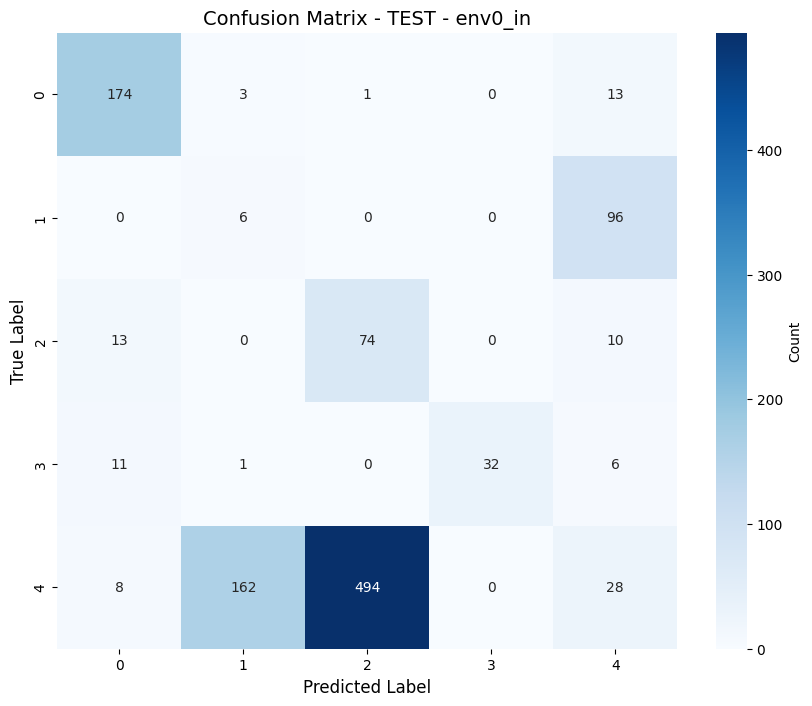


TRAIN - env1_in:
  Loss: 0.0005
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env1_in.png


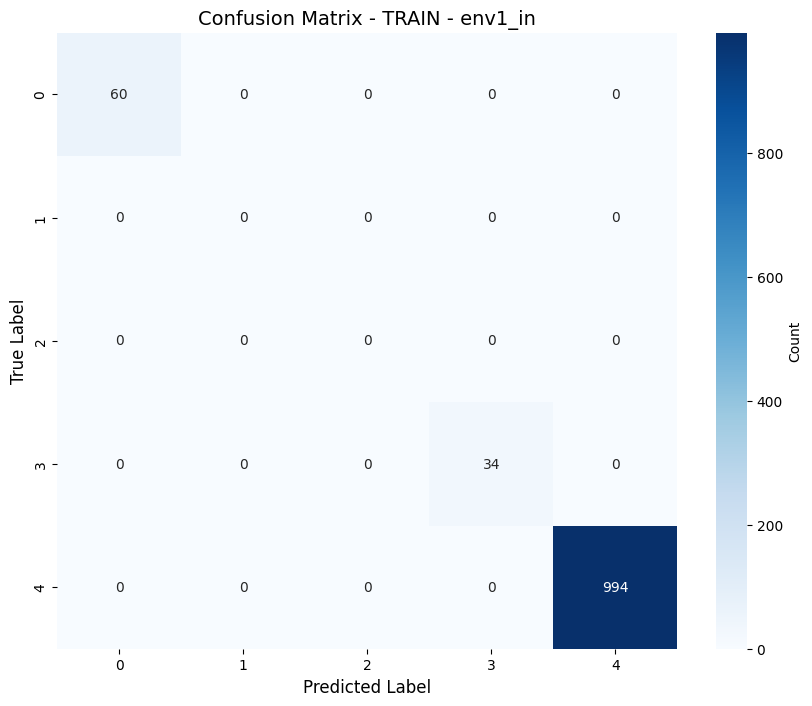


TRAIN - env2_in:
  Loss: 0.0016
  Accuracy: 0.7498, Precision: 0.7500, Recall: 0.7498, F1: 0.7499
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env2_in.png


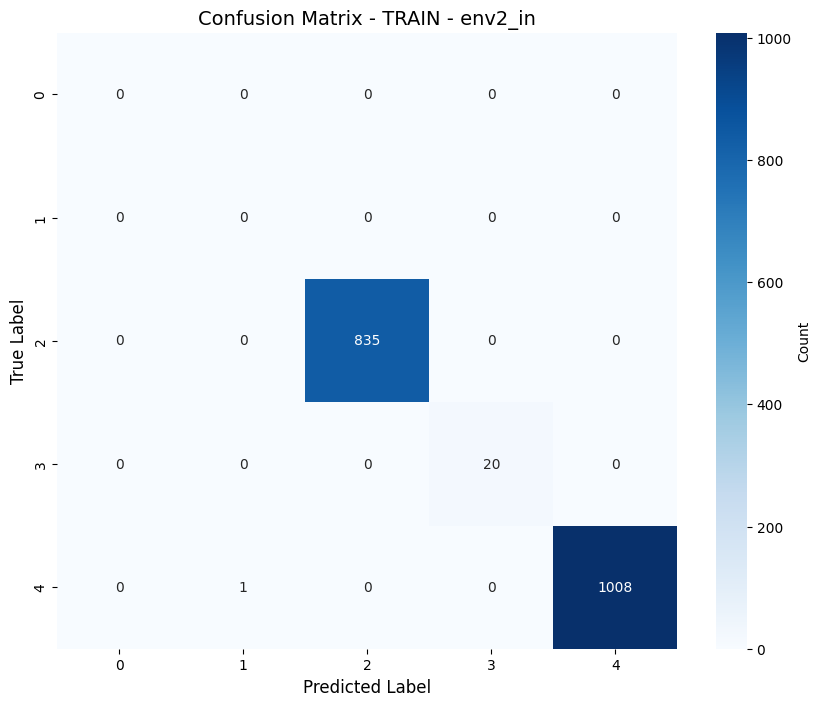


TRAIN - env3_in:
  Loss: 0.0004
  Accuracy: 0.9990, Precision: 0.9994, Recall: 0.9990, F1: 0.9992
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_TRAIN_env3_in.png


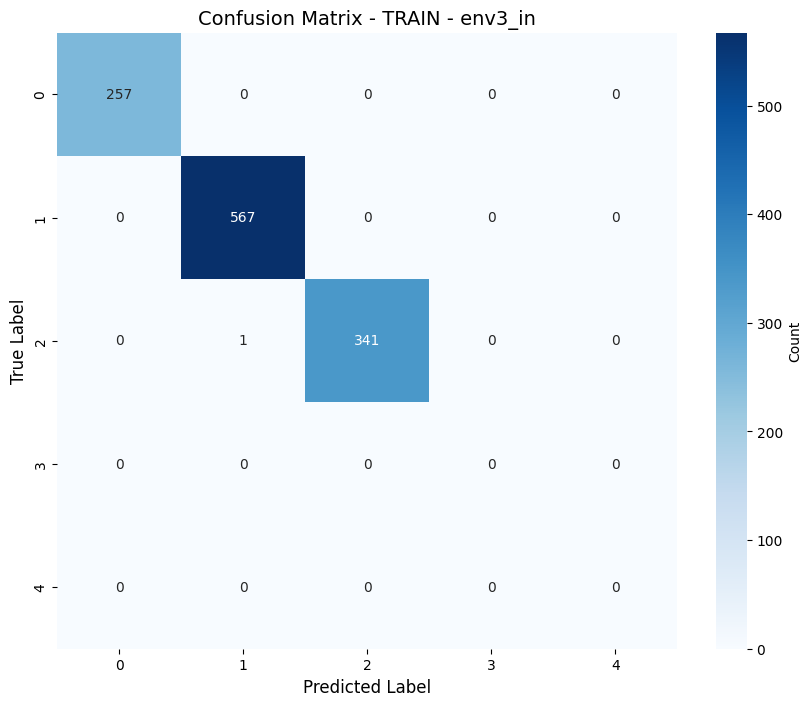


OTHER - env0_out:
  Loss: 5.2438
  Accuracy: 0.4499, Precision: 0.4017, Recall: 0.4499, F1: 0.3587
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_OTHER_env0_out.png


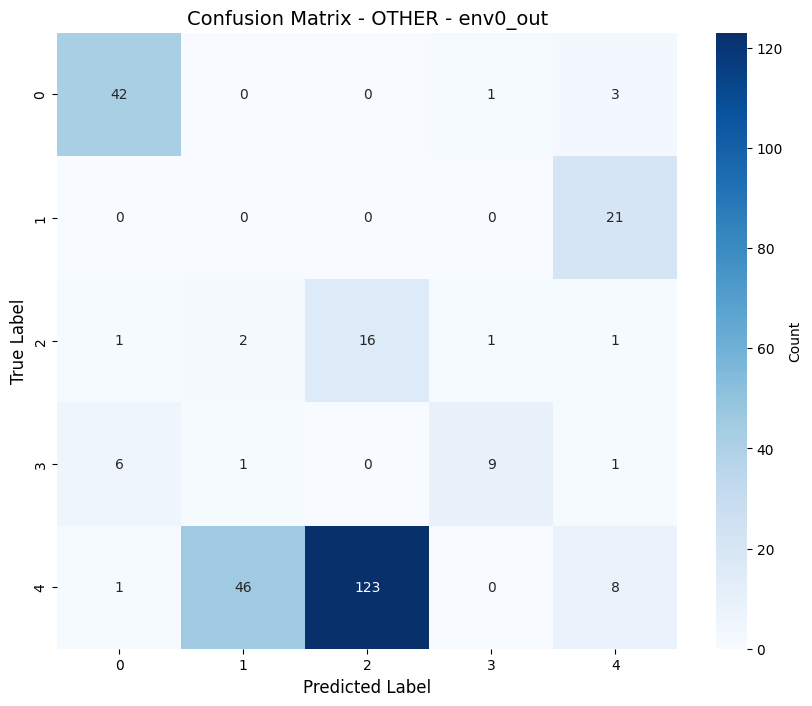


VAL - env1_out:
  Loss: 0.7866
  Accuracy: 0.3409, Precision: 0.3666, Recall: 0.3409, F1: 0.3527
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env1_out.png


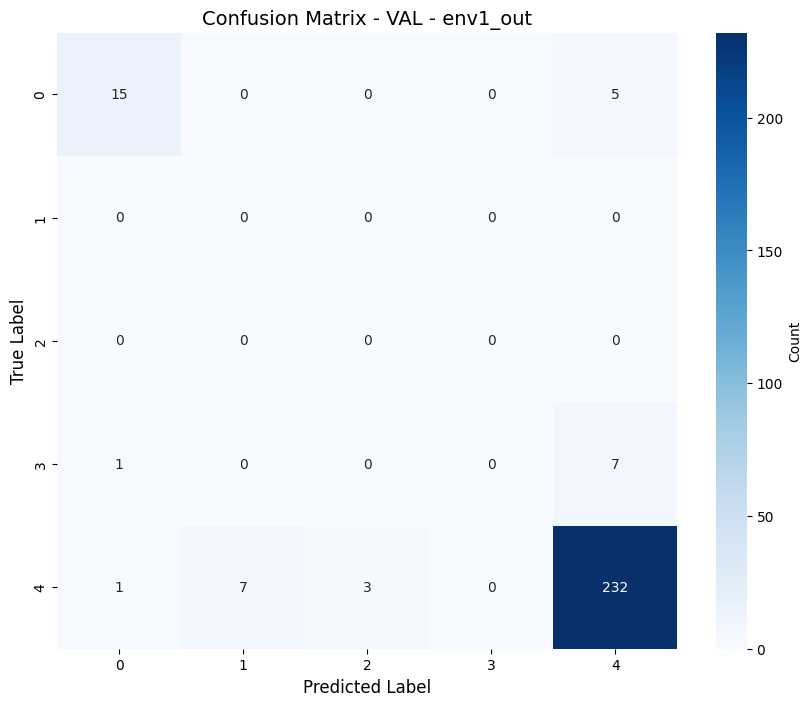


VAL - env2_out:
  Loss: 1.0466
  Accuracy: 0.3736, Precision: 0.4151, Recall: 0.3736, F1: 0.3877
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env2_out.png


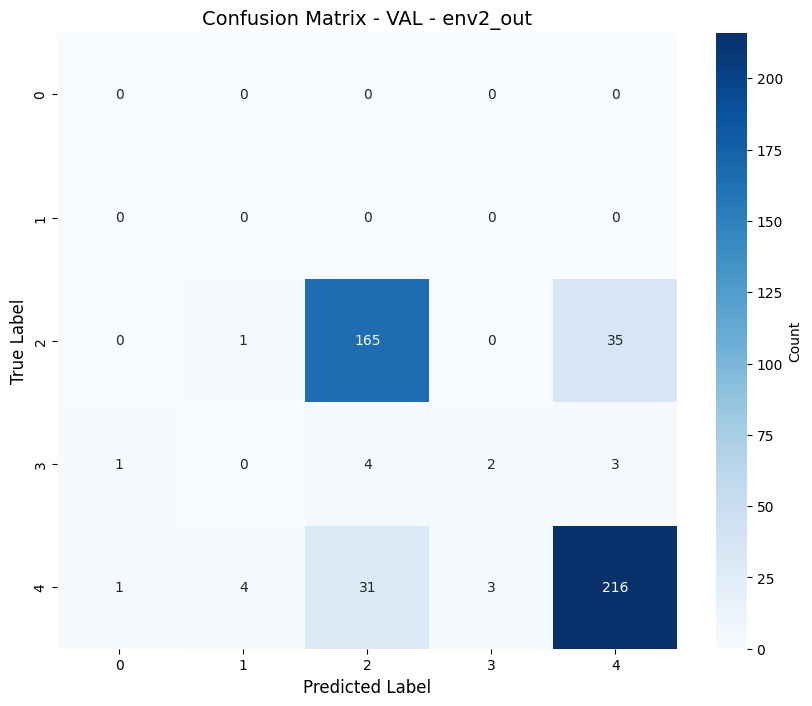


VAL - env3_out:
  Loss: 1.3620
  Accuracy: 0.4903, Precision: 0.5614, Recall: 0.4903, F1: 0.5233
  Saved CSV to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/confusion_matrix_VAL_env3_out.png


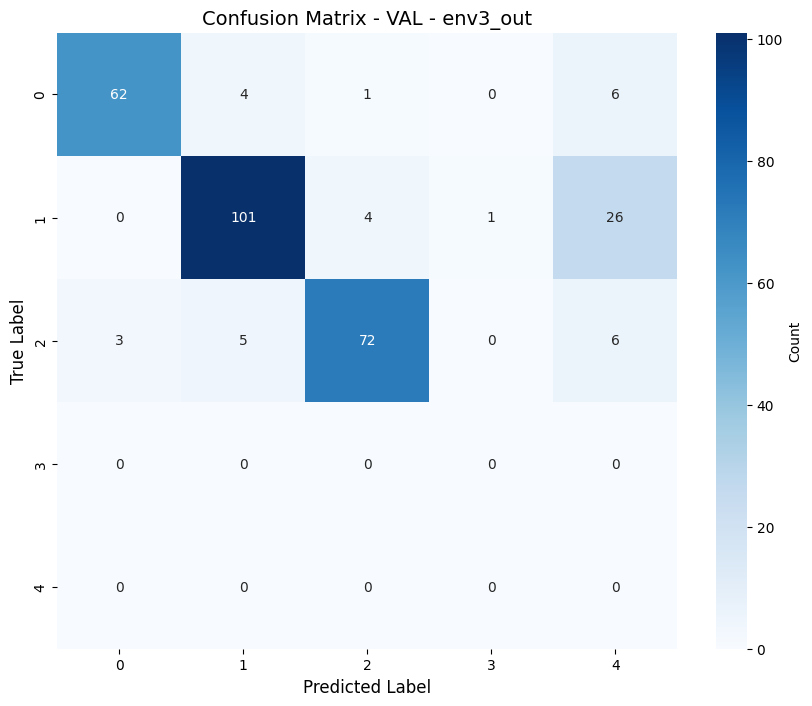


Training curves saved to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/training_curves_VLCS.png


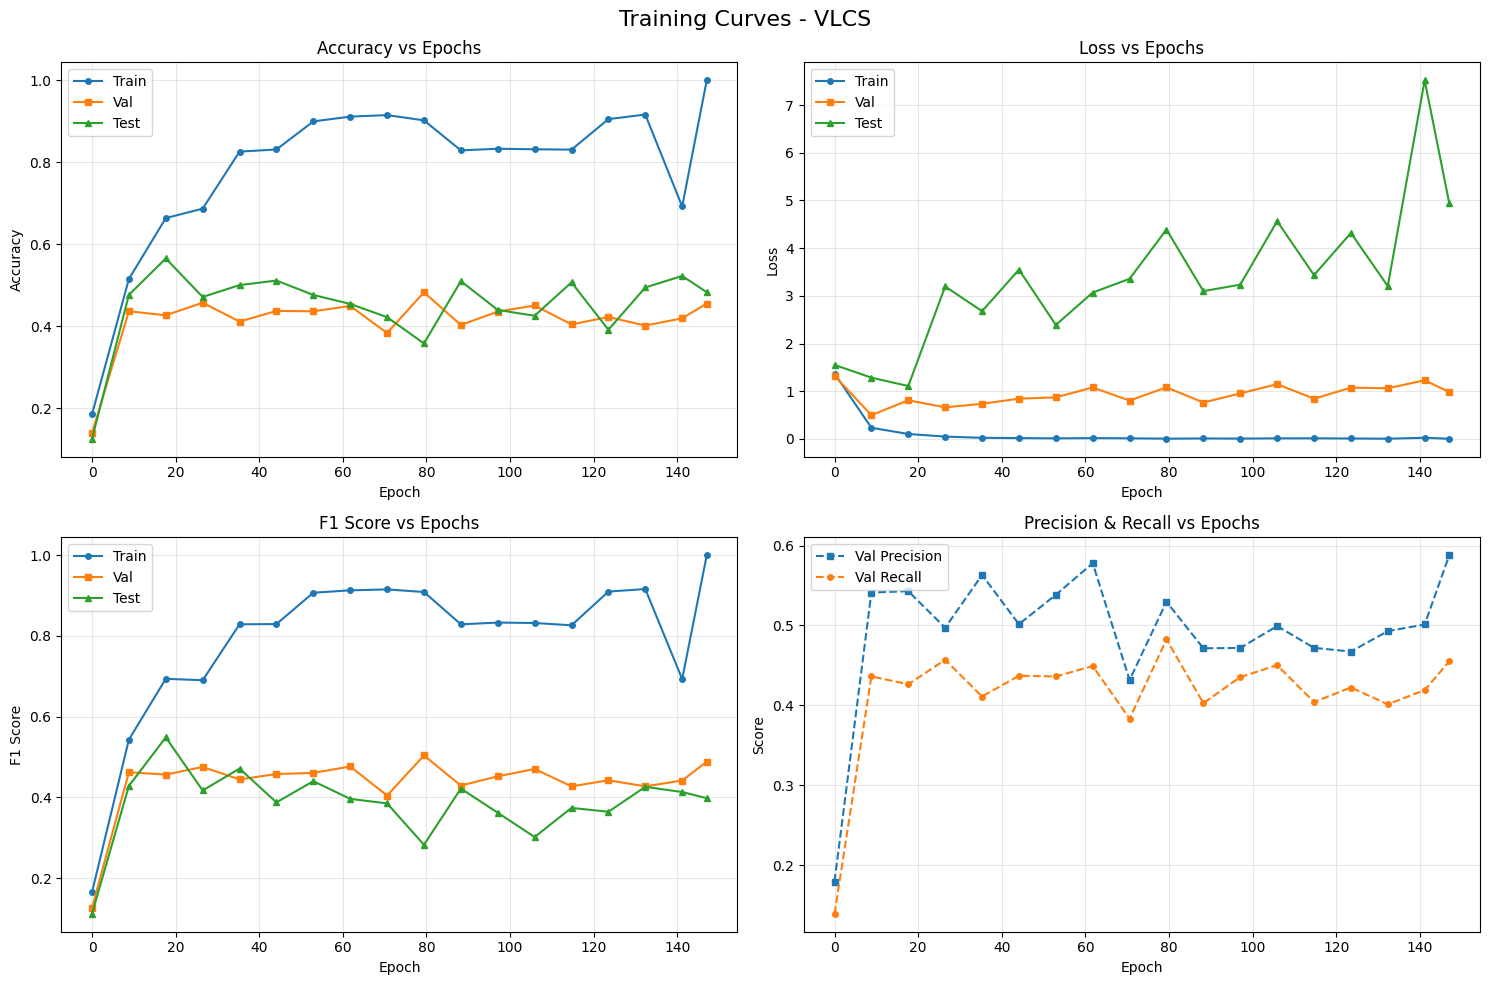

Epoch time plot saved to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs/epoch_times_VLCS.png


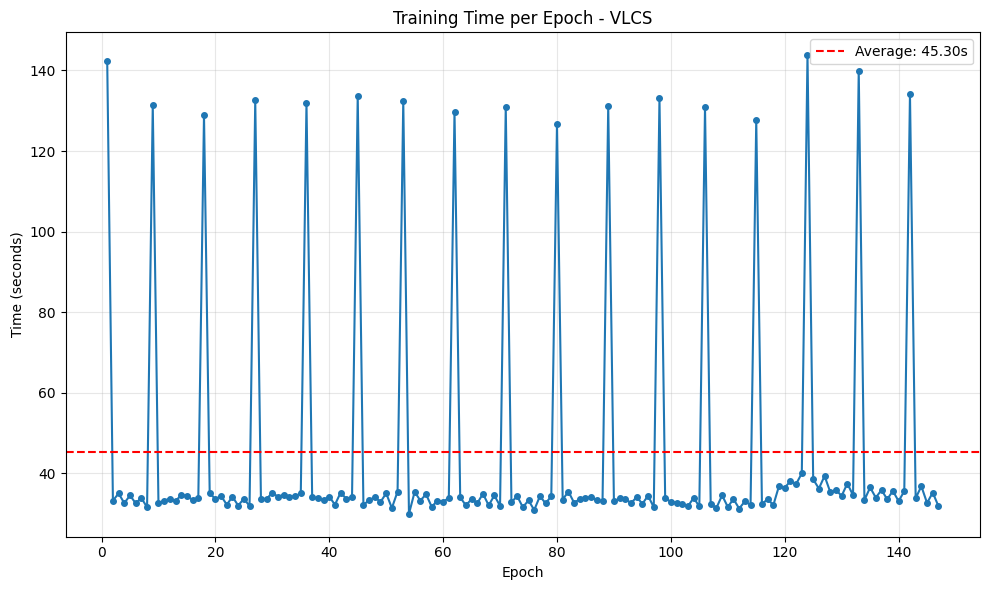


All results saved to: /kaggle/working/experiments/experiment_with_vlcs_SimpleDiffAug/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_VLCS.png
  - epoch_times_VLCS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)


In [ ]:
# Archived output copied from dada-1.ipynb cell 74.
# Historical ERM result only; not FOND+DADA.

In [ ]:
from pathlib import Path
import shutil

zip_base = Path("/kaggle/working") / OUTPUT_ROOT.name
zip_path = Path(shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUTPUT_ROOT.parent,
    base_dir=OUTPUT_ROOT.name,
))
print(f"Updated full output archive: {zip_path}")


## Held-out domain 1: LabelMe

Run the next cell to train FOND+DADA with this domain held out and the other three as sources.


Seed set to 1


num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 13.9MB/s]


Model checkpoint frequency: 300


  0%|          | 0/5001 [02:57<?, ?it/s]

...


=== Step 4500 (Epoch 375.98) ===
step_time: 165.7775s
TRAIN:
  loss: 0.8593
  acc: 0.7719
  precision: 0.7701
  recall: 0.7719
  f1: 0.7707
  oacc: 0.6525
  nacc: 0.3333
VAL:
  loss: 0.5509
  acc: 0.6668
  precision: 0.7037
  recall: 0.6668
  f1: 0.6810
  oacc: 0.5001
  nacc: 0.3333
TEST:
  loss: 4.2730
  acc: 0.3476
  precision: 0.5672
  recall: 0.3476
  f1: 0.3599
  oacc: 0.3959
  nacc: 0.1544
OTHER:
  loss: 3.7391
  acc: 0.3923
  precision: 0.5079
  recall: 0.3923
  f1: 0.3872
  oacc: 0.4481
  nacc: 0.1688


 96%|█████████▌| 4801/5001 [1:26:12<2:46:00, 49.80s/it]


=== Step 4800 (Epoch 401.04) ===
step_time: 164.7276s
TRAIN:
  loss: 0.8719
  acc: 0.8175
  precision: 0.7851
  recall: 0.8175
  f1: 0.7987
  oacc: 0.6510
  nacc: 0.3333
VAL:
  loss: 0.5382
  acc: 0.6628
  precision: 0.6640
  recall: 0.6628
  f1: 0.6593
  oacc: 0.4962
  nacc: 0.3333
TEST:
  loss: 4.0597
  acc: 0.3520
  precision: 0.5363
  recall: 0.3520
  f1: 0.3499
  oacc: 0.4124
  nacc: 0.1104
OTHER:
  loss: 3.7622
  acc: 0.3589
  precision: 0.5287
  recall: 0.3589
  f1: 0.3564
  oacc: 0.4216
  nacc: 0.1082


100%|██████████| 5001/5001 [1:30:36<00:00,  1.09s/it]  



=== Step 5000 (Epoch 417.75) ===
step_time: 164.8653s
TRAIN:
  loss: 0.8485
  acc: 0.8280
  precision: 0.8167
  recall: 0.8280
  f1: 0.8221
  oacc: 0.6614
  nacc: 0.3333
VAL:
  loss: 0.5435
  acc: 0.6699
  precision: 0.6787
  recall: 0.6699
  f1: 0.6688
  oacc: 0.5032
  nacc: 0.3333
TEST:
  loss: 3.5214
  acc: 0.3748
  precision: 0.4883
  recall: 0.3748
  f1: 0.3671
  oacc: 0.4174
  nacc: 0.2045
OTHER:
  loss: 3.0987
  acc: 0.4148
  precision: 0.5351
  recall: 0.4148
  f1: 0.4224
  oacc: 0.4600
  nacc: 0.2338

TRAINING COMPLETED
Total training time: 5436.66s (90.61 minutes)
Average time per epoch: 12.66s
Total epochs: 416


FINAL EVALUATION - CONFUSION MATRICES

TRAIN - env0_in:
  Loss: 0.0044
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env0_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env0_in.png


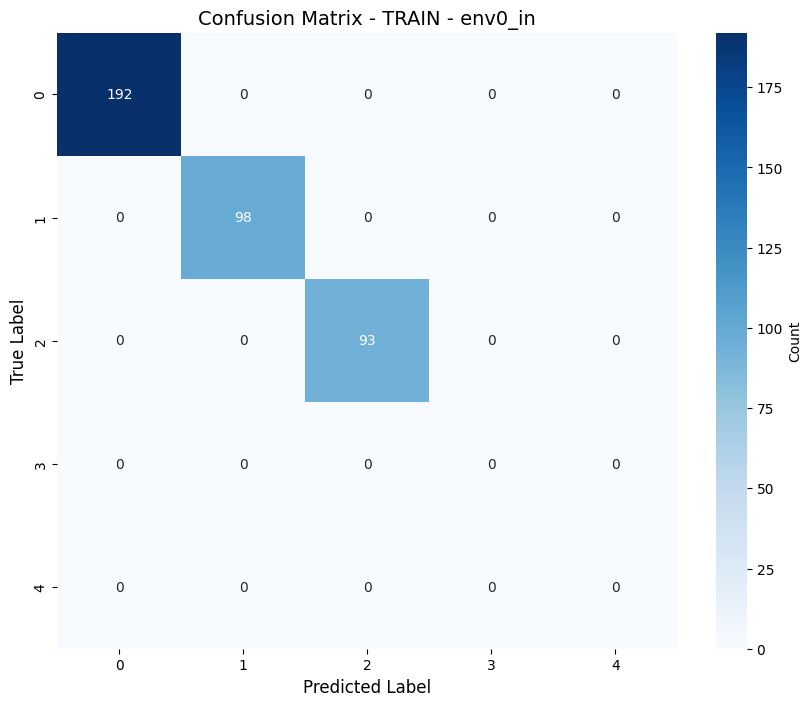


TEST - env1_in:
  Loss: 3.5016
  Accuracy: 0.3748, Precision: 0.4883, Recall: 0.3748, F1: 0.3671
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TEST_env1_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TEST_env1_in.png


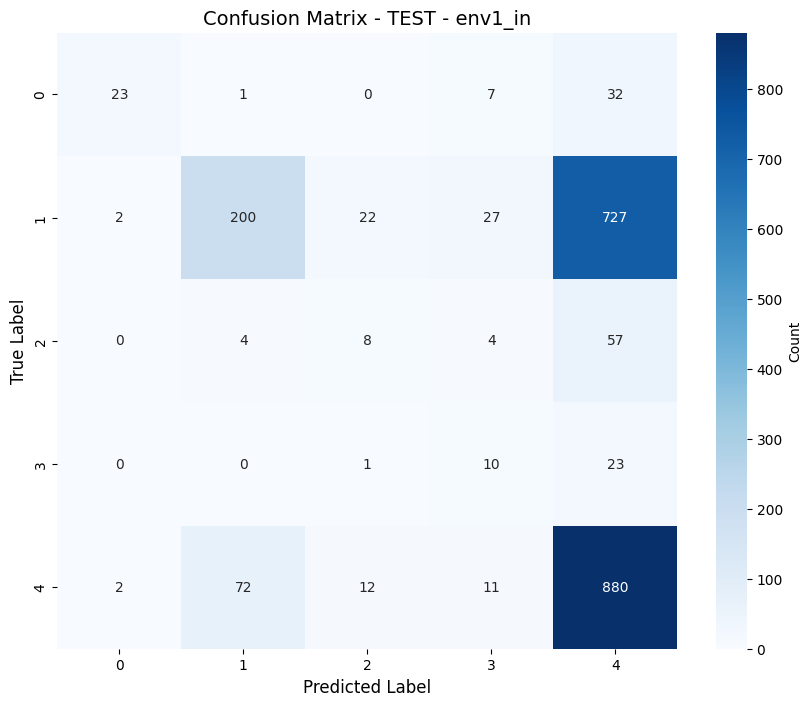


TRAIN - env2_in:
  Loss: 0.0184
  Accuracy: 0.7478, Precision: 0.7252, Recall: 0.7478, F1: 0.7362
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env2_in.png


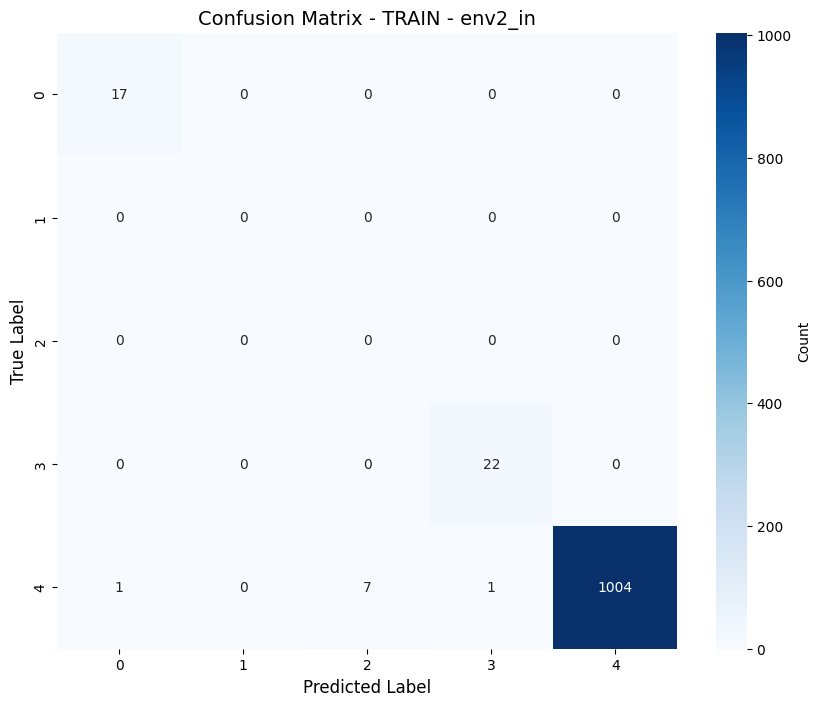


TRAIN - env3_in:
  Loss: 0.0486
  Accuracy: 0.7361, Precision: 0.7372, Recall: 0.7361, F1: 0.7366
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_TRAIN_env3_in.png


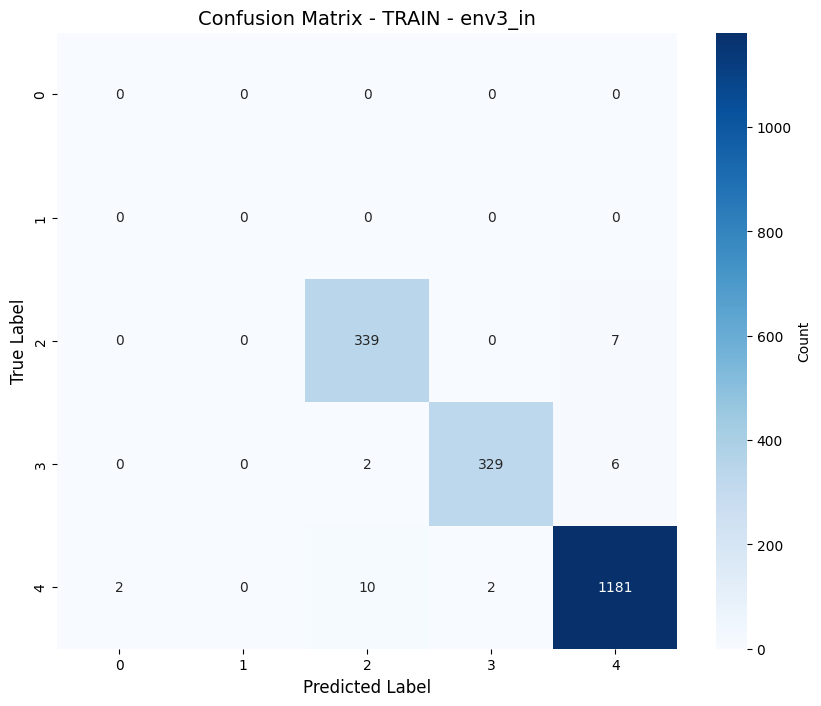


VAL - env0_out:
  Loss: 0.0131
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env0_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env0_out.png


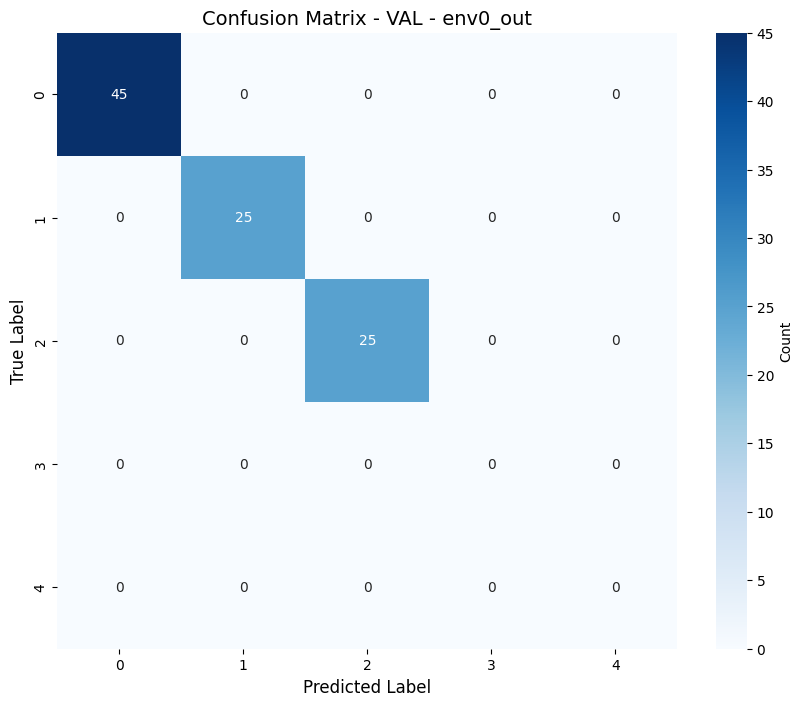


OTHER - env1_out:
  Loss: 3.1243
  Accuracy: 0.4148, Precision: 0.5351, Recall: 0.4148, F1: 0.4224
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_OTHER_env1_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_OTHER_env1_out.png


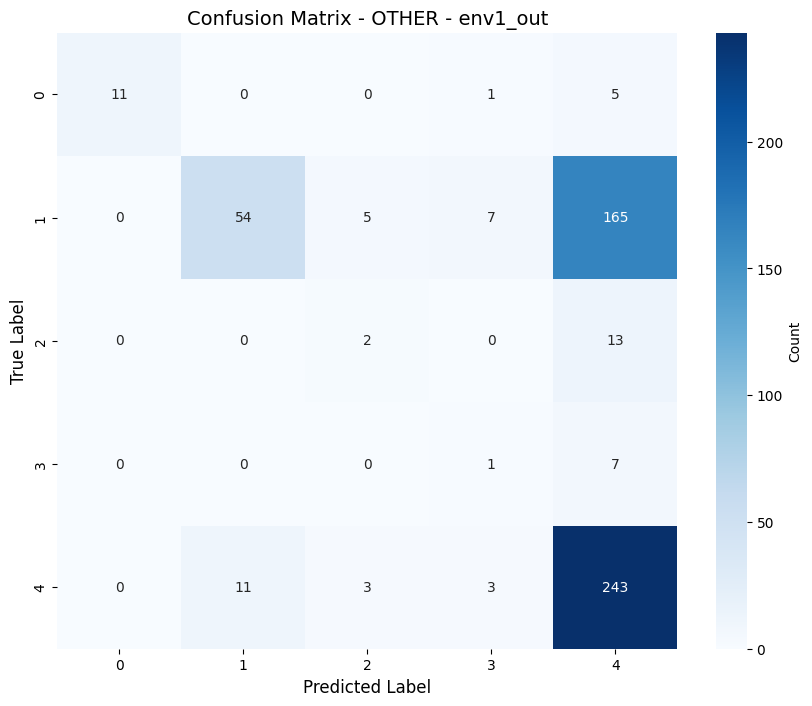


VAL - env2_out:
  Loss: 0.4913
  Accuracy: 0.4602, Precision: 0.5364, Recall: 0.4602, F1: 0.4715
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env2_out.png


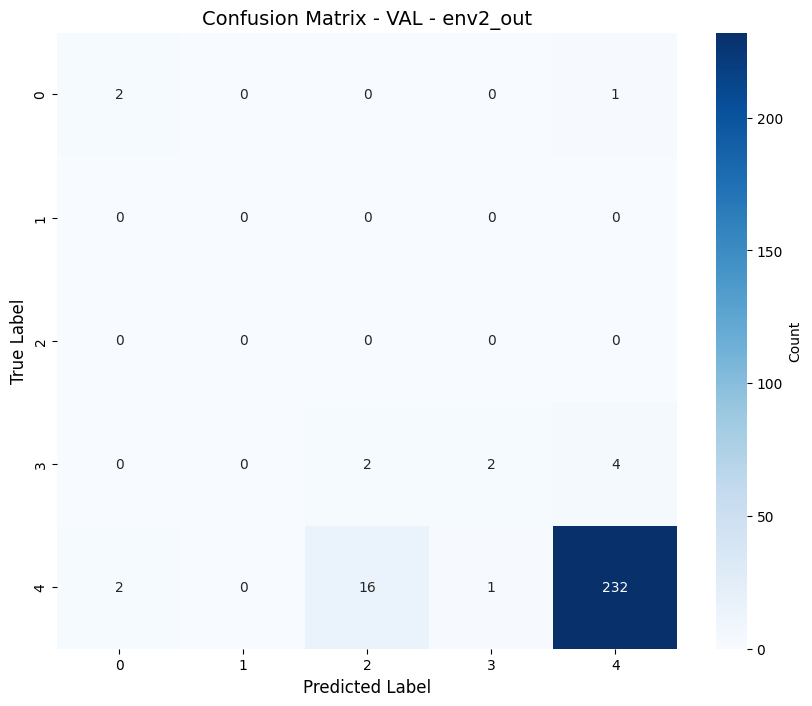


VAL - env3_out:
  Loss: 0.9288
  Accuracy: 0.5530, Precision: 0.5960, Recall: 0.5530, F1: 0.5681
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/confusion_matrix_VAL_env3_out.png


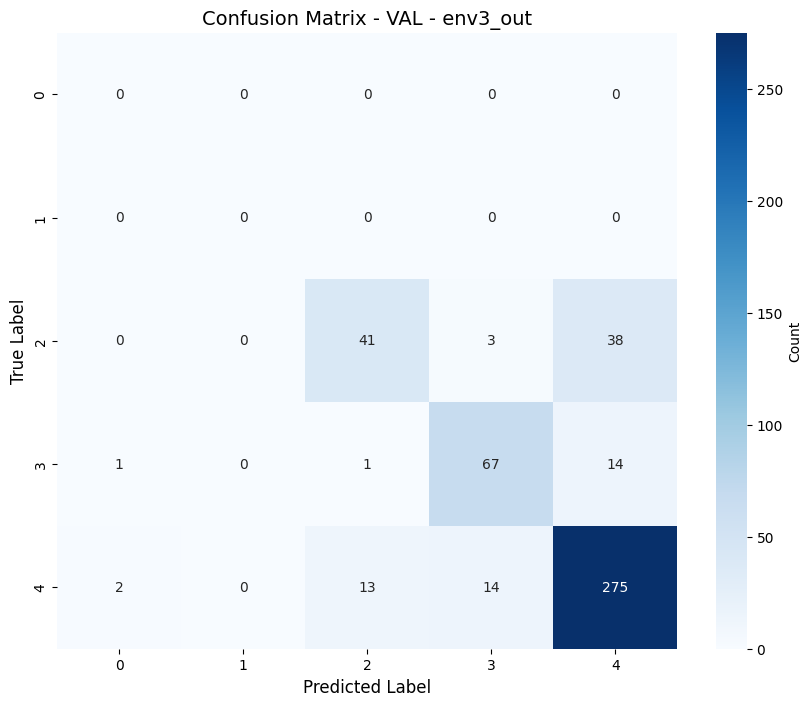


Training curves saved to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/training_curves_VLCS.png


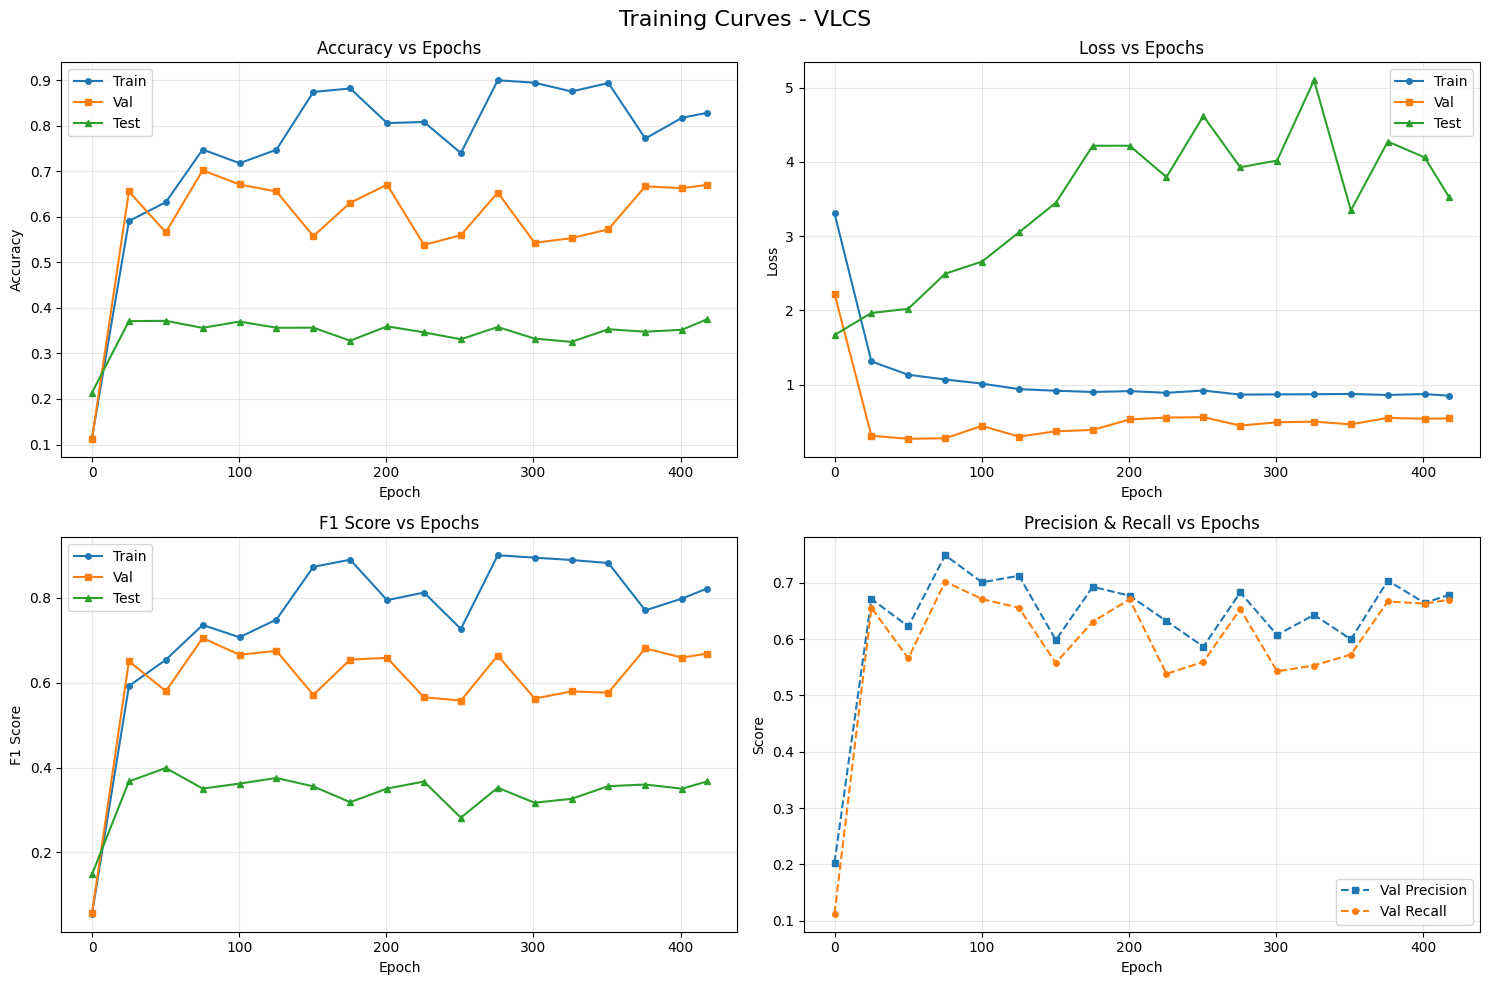

Epoch time plot saved to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs/epoch_times_VLCS.png


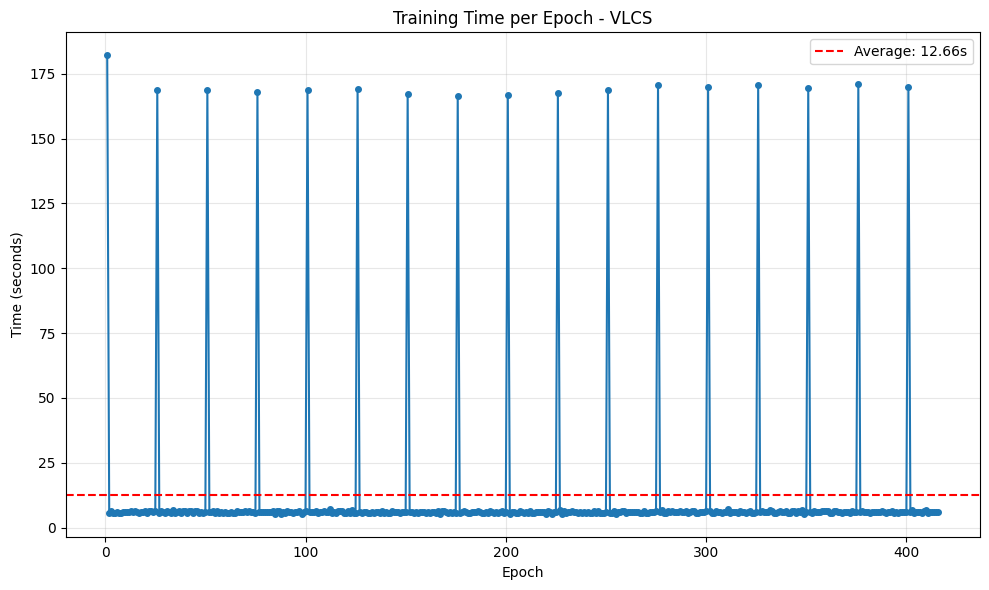


All results saved to: /kaggle/working/fond_dada_lodo_vlcs/test_1_LabelMe/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_VLCS.png
  - epoch_times_VLCS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)
Held out LabelMe (ID 1)
Source domains: Caltech101; SUN09; VOC2007
Selected checkpoint: 3
Validation accuracy: 0.7021
Held-out test accuracy: 0.3561
Saved per-domain results to: /kaggle/working/fond_dada_lodo_vlcs/point7_lodo_per_domain_results.csv


{'dataset': 'VLCS',
 'held_out_domain_id': 1,
 'held_out_domain': 'LabelMe',
 'source_domains': 'Caltech101; SUN09; VOC2007',
 'selected_checkpoint_index': 3,
 'validation_accuracy_at_selected_checkpoint': 0.7020720541477203,
 'held_out_test_accuracy_at_selected_checkpoint': 0.35607075691223145}

In [31]:
run_lodo_domain(1, "LabelMe")


In [32]:
from pathlib import Path
import shutil

zip_base = Path("/kaggle/working") / OUTPUT_ROOT.name
zip_path = Path(shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUTPUT_ROOT.parent,
    base_dir=OUTPUT_ROOT.name,
))
print(f"Updated full output archive: {zip_path}")


Updated full output archive: /kaggle/working/fond_dada_lodo_vlcs.zip


## Held-out domain 2: SUN09

Run the next cell to train FOND+DADA with this domain held out and the other three as sources.


Seed set to 1


num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]
Model checkpoint frequency: 300


  0%|          | 0/5001 [02:09<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 129.1416s
TRAIN:
  loss: 2.9246
  acc: 0.1695
  precision: 0.2303
  recall: 0.1695
  f1: 0.1546
  oacc: 0.1700
  nacc: 0.0000
VAL:
  loss: 1.5893
  acc: 0.1702
  precision: 0.1479
  recall: 0.1702
  f1: 0.1541
  oacc: 0.1720
  nacc: 0.0000
TEST:
  loss: 1.7124
  acc: 0.1902
  precision: 0.1919
  recall: 0.1902
  f1: 0.1363
  oacc: 0.2378
  nacc: 0.0000
OTHER:
  loss: 1.7250
  acc: 0.1723
  precision: 0.1859
  recall: 0.1723
  f1: 0.1365
  oacc: 0.2154
  nacc: 0.0000


  6%|▌         | 300/5001 [09:22<1:40:32,  1.28s/it] 

...


=== Step 4500 (Epoch 170.62) ===
step_time: 117.5528s
TRAIN:
  loss: 0.8579
  acc: 0.7719
  precision: 0.7753
  recall: 0.7719
  f1: 0.7735
  oacc: 0.6539
  nacc: 0.3326
VAL:
  loss: 0.4265
  acc: 0.6243
  precision: 0.6998
  recall: 0.6243
  f1: 0.6429
  oacc: 0.5321
  nacc: 0.3263
TEST:
  loss: 3.2136
  acc: 0.4535
  precision: 0.3913
  recall: 0.4535
  f1: 0.3452
  oacc: 0.3552
  nacc: 0.8466
OTHER:
  loss: 3.5312
  acc: 0.5736
  precision: 0.3708
  recall: 0.5736
  f1: 0.3330
  oacc: 0.5160
  nacc: 0.8042


 96%|█████████▌| 4801/5001 [1:59:15<1:59:42, 35.91s/it]


=== Step 4800 (Epoch 181.99) ===
step_time: 117.3437s
TRAIN:
  loss: 0.8649
  acc: 0.7726
  precision: 0.7724
  recall: 0.7726
  f1: 0.7725
  oacc: 0.6552
  nacc: 0.3302
VAL:
  loss: 0.3801
  acc: 0.6660
  precision: 0.7269
  recall: 0.6660
  f1: 0.6889
  oacc: 0.5438
  nacc: 0.3193
TEST:
  loss: 2.8201
  acc: 0.4484
  precision: 0.3877
  recall: 0.4484
  f1: 0.3699
  oacc: 0.3620
  nacc: 0.7941
OTHER:
  loss: 2.9914
  acc: 0.6024
  precision: 0.4049
  recall: 0.6024
  f1: 0.3914
  oacc: 0.5573
  nacc: 0.7831


100%|██████████| 5001/5001 [2:04:41<00:00,  1.50s/it]  



=== Step 5000 (Epoch 189.57) ===
step_time: 117.5478s
TRAIN:
  loss: 0.8658
  acc: 0.7724
  precision: 0.7624
  recall: 0.7724
  f1: 0.7670
  oacc: 0.6560
  nacc: 0.3268
VAL:
  loss: 0.4202
  acc: 0.6268
  precision: 0.6736
  recall: 0.6268
  f1: 0.6463
  oacc: 0.5377
  nacc: 0.3165
TEST:
  loss: 2.5470
  acc: 0.4859
  precision: 0.4034
  recall: 0.4859
  f1: 0.3954
  oacc: 0.4170
  nacc: 0.7618
OTHER:
  loss: 2.7449
  acc: 0.5937
  precision: 0.3934
  recall: 0.5937
  f1: 0.3846
  oacc: 0.5556
  nacc: 0.7460

TRAINING COMPLETED
Total training time: 7481.52s (124.69 minutes)
Average time per epoch: 39.78s
Total epochs: 185


FINAL EVALUATION - CONFUSION MATRICES

TRAIN - env0_in:
  Loss: 0.0000
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env0_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env0_in.png


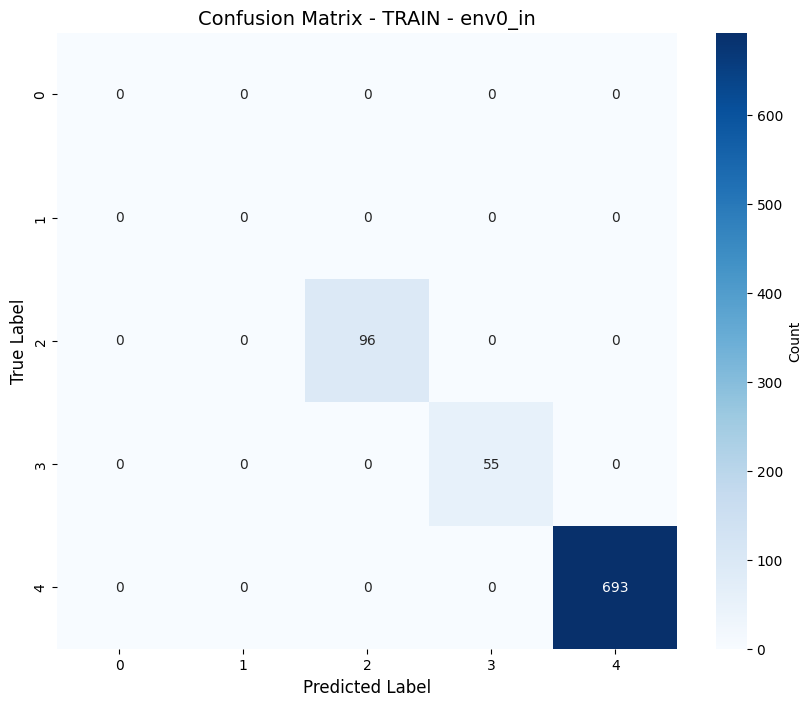


TRAIN - env1_in:
  Loss: 0.0728
  Accuracy: 0.7340, Precision: 0.7155, Recall: 0.7340, F1: 0.7242
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env1_in.png


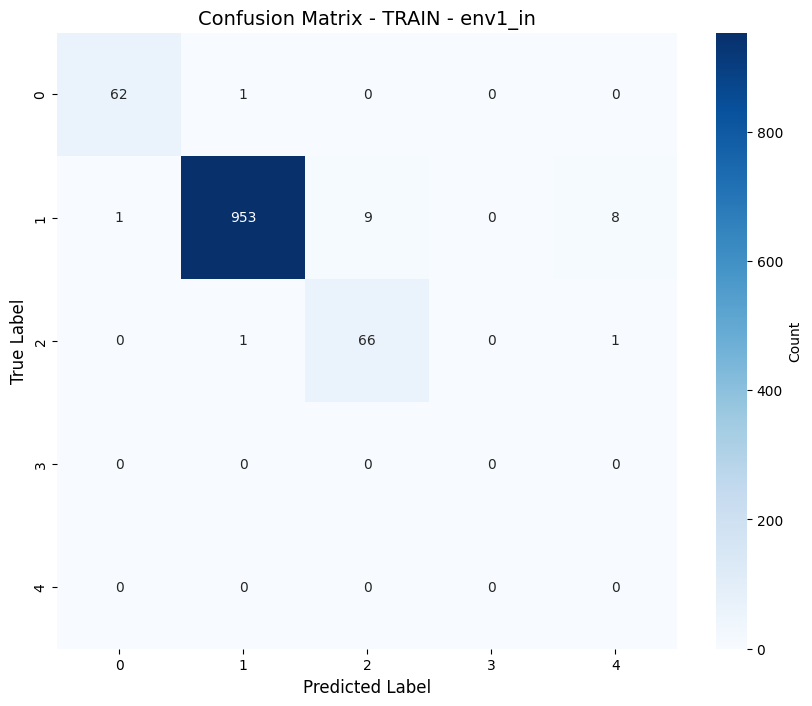


TEST - env2_in:
  Loss: 2.5615
  Accuracy: 0.4859, Precision: 0.4034, Recall: 0.4859, F1: 0.3954
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TEST_env2_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TEST_env2_in.png


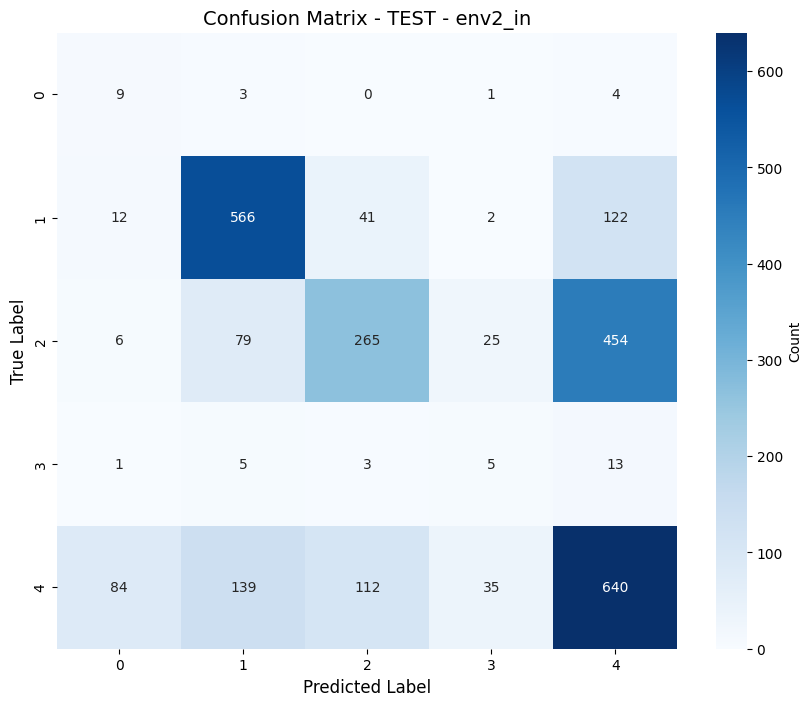


TRAIN - env3_in:
  Loss: 0.0433
  Accuracy: 0.7341, Precision: 0.7414, Recall: 0.7341, F1: 0.7377
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_TRAIN_env3_in.png


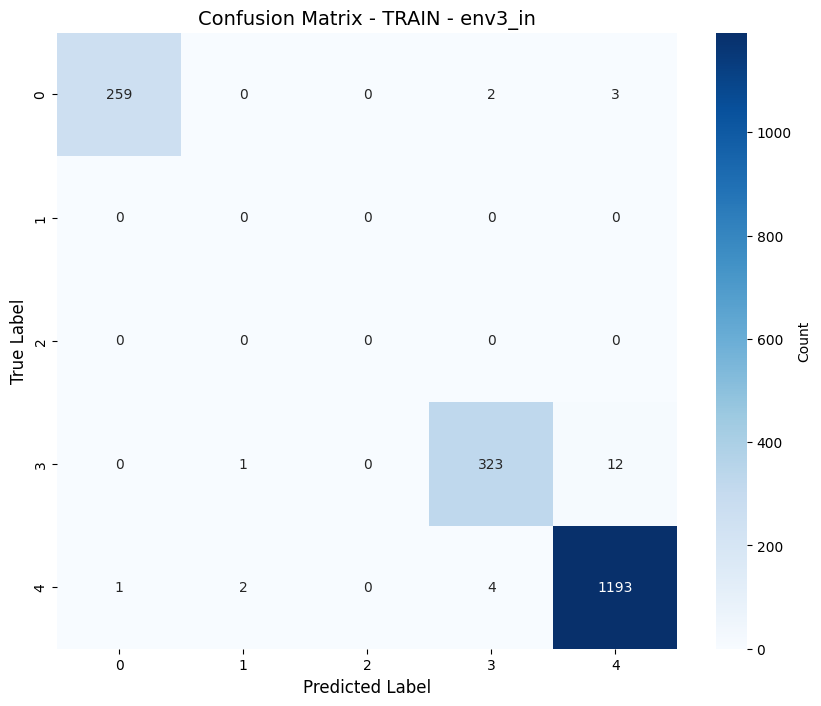


VAL - env0_out:
  Loss: 0.0000
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env0_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env0_out.png


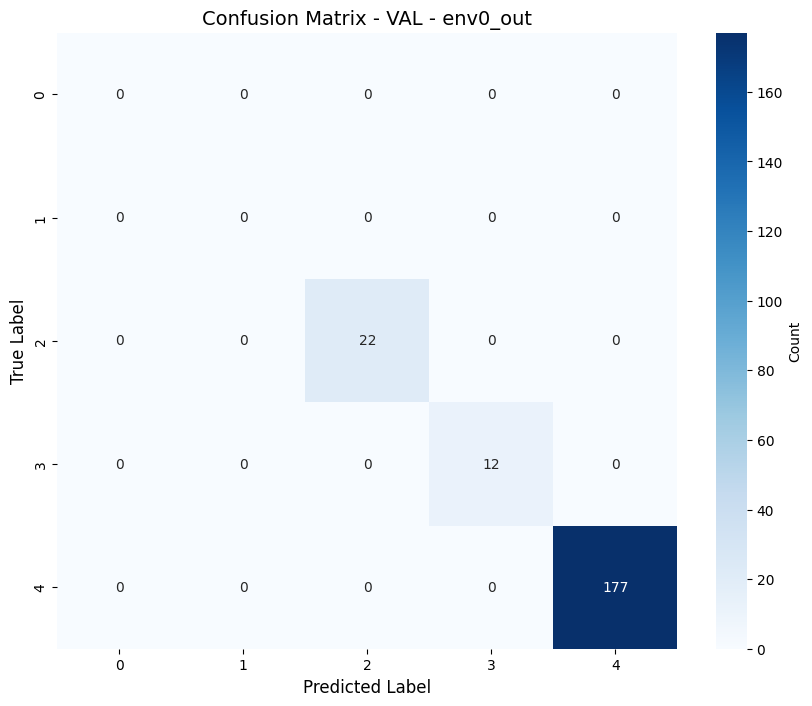


VAL - env1_out:
  Loss: 0.5752
  Accuracy: 0.3642, Precision: 0.4532, Recall: 0.3642, F1: 0.4004
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env1_out.png


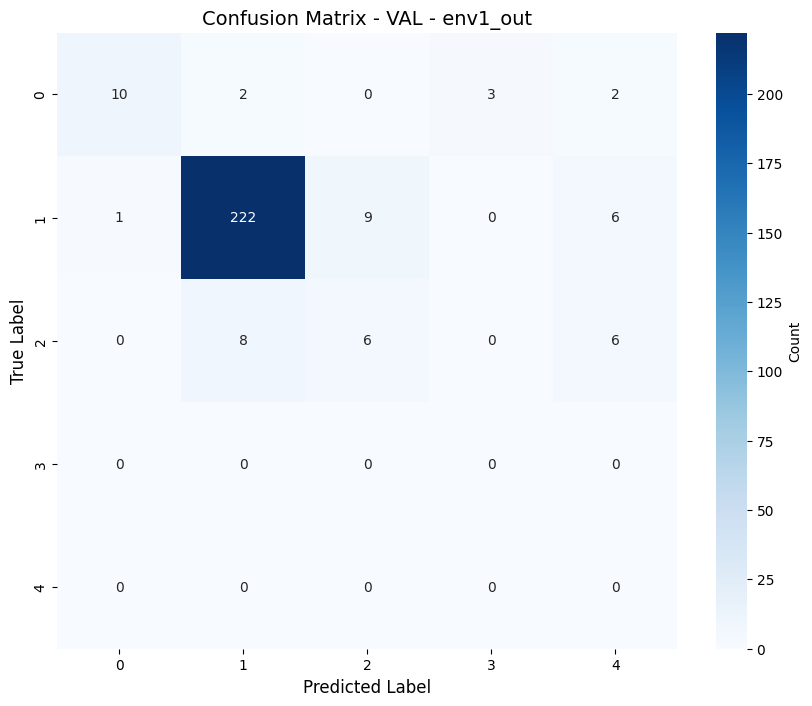


OTHER - env2_out:
  Loss: 2.8181
  Accuracy: 0.5937, Precision: 0.3934, Recall: 0.5937, F1: 0.3846
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_OTHER_env2_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_OTHER_env2_out.png


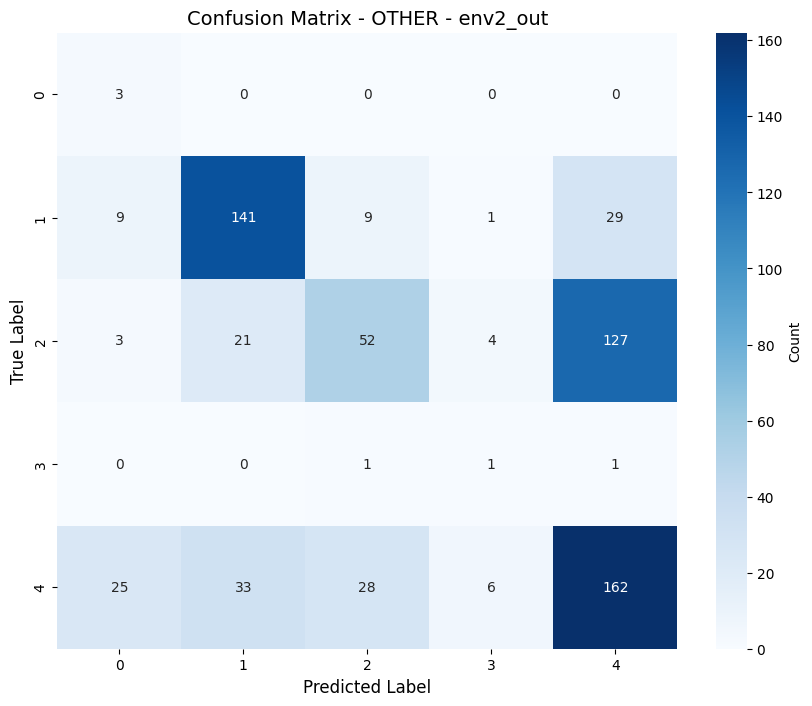


VAL - env3_out:
  Loss: 0.7675
  Accuracy: 0.4689, Precision: 0.5181, Recall: 0.4689, F1: 0.4903
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/confusion_matrix_VAL_env3_out.png


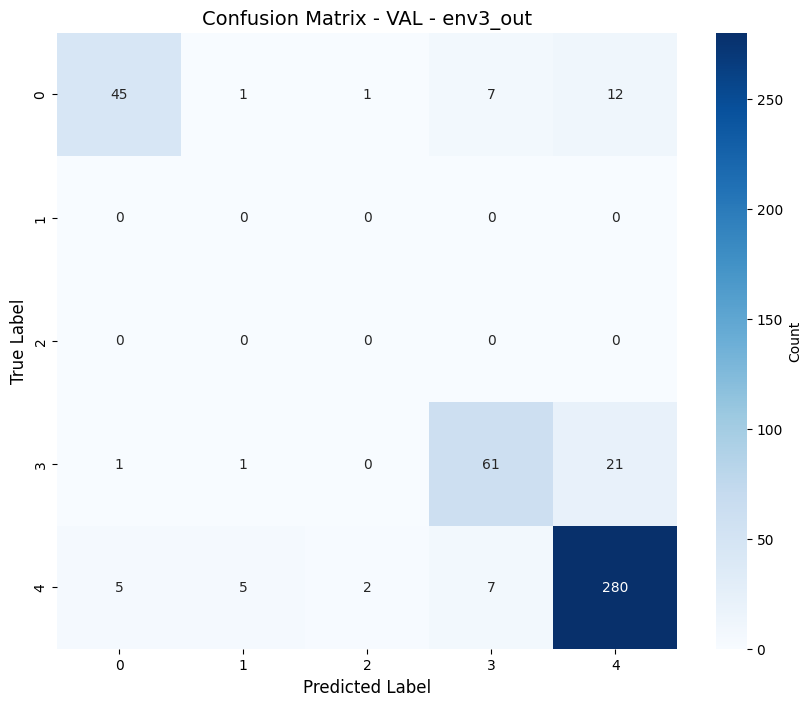


Training curves saved to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/training_curves_VLCS.png


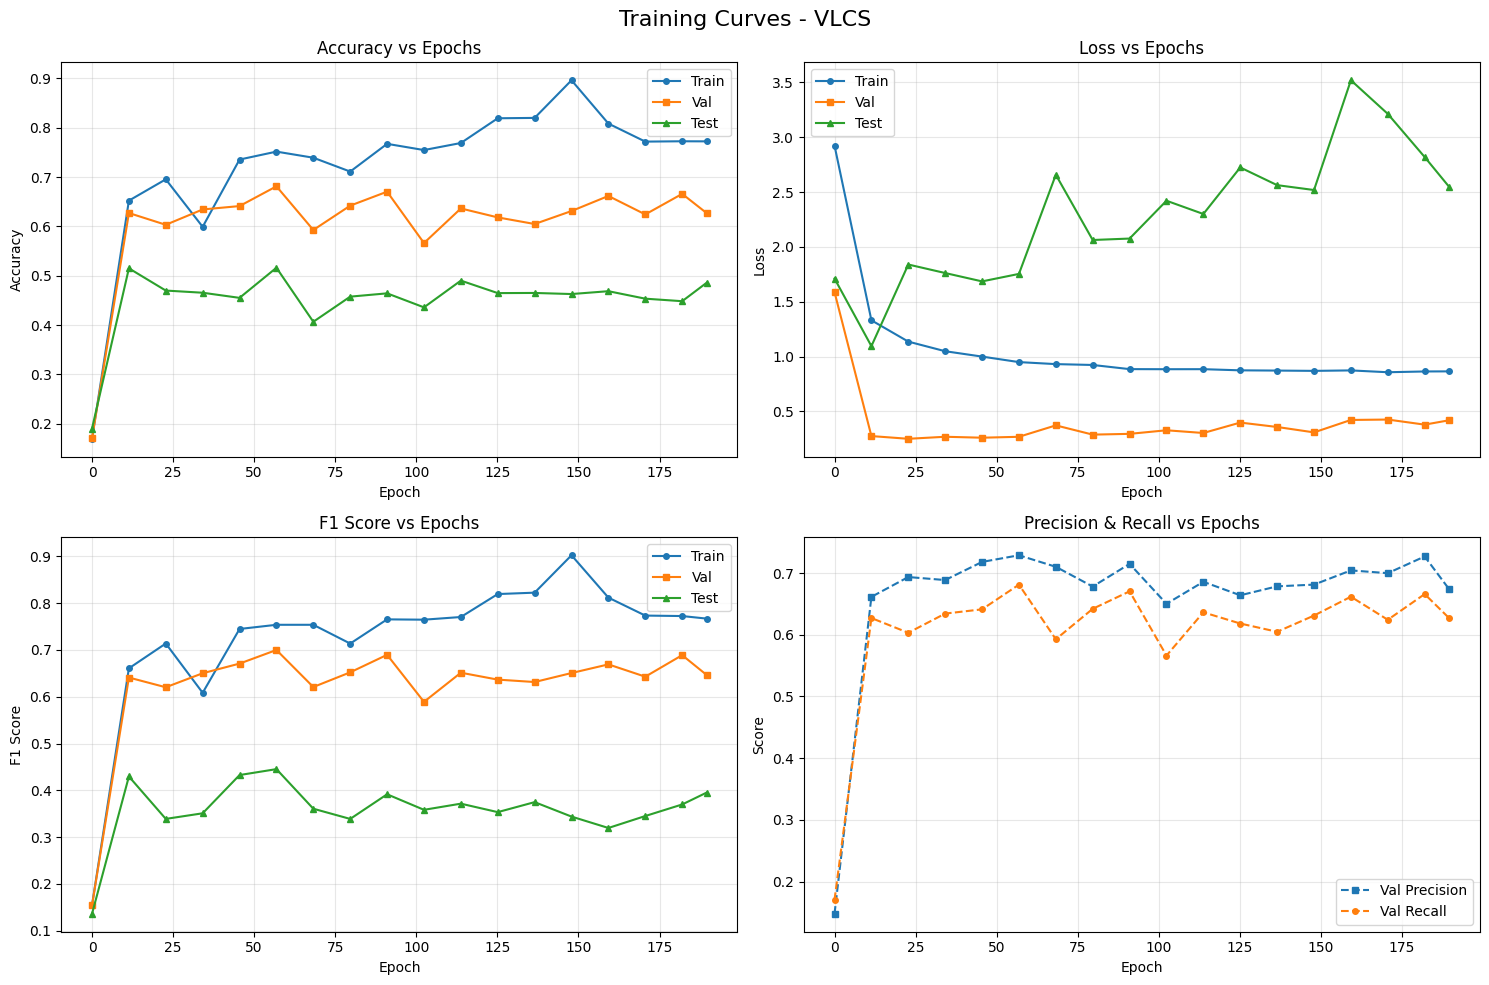

Epoch time plot saved to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs/epoch_times_VLCS.png


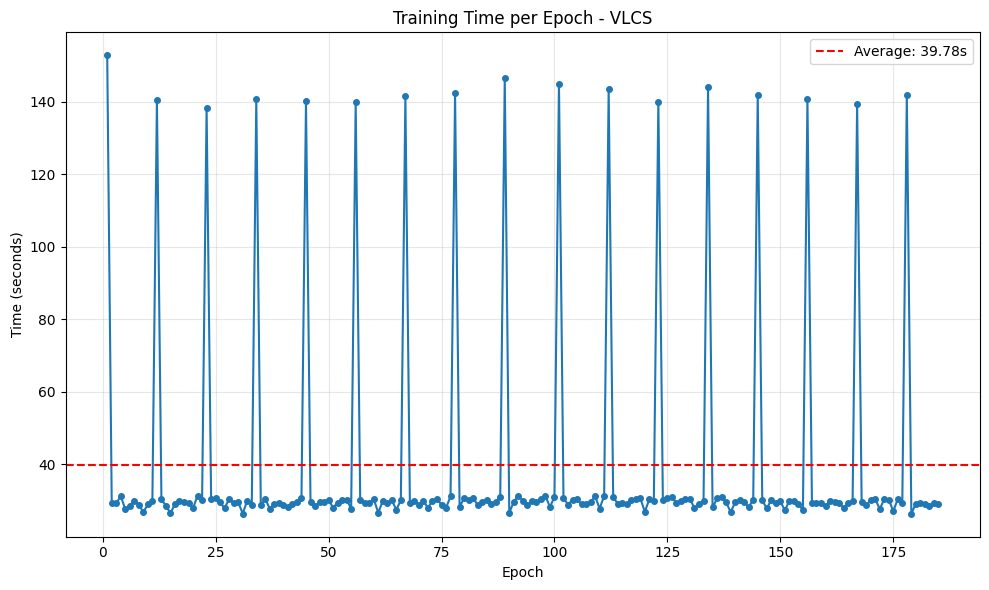


All results saved to: /kaggle/working/fond_dada_lodo_vlcs/test_2_SUN09/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_VLCS.png
  - epoch_times_VLCS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)
Held out SUN09 (ID 2)
Source domains: Caltech101; LabelMe; VOC2007
Selected checkpoint: 5
Validation accuracy: 0.6813
Held-out test accuracy: 0.5162
Saved per-domain results to: /kaggle/working/fond_dada_lodo_vlcs/point7_lodo_per_domain_results.csv


{'dataset': 'VLCS',
 'held_out_domain_id': 2,
 'held_out_domain': 'SUN09',
 'source_domains': 'Caltech101; LabelMe; VOC2007',
 'selected_checkpoint_index': 5,
 'validation_accuracy_at_selected_checkpoint': 0.6812763512134552,
 'held_out_test_accuracy_at_selected_checkpoint': 0.5162314176559448}

In [33]:
run_lodo_domain(2, "SUN09")


In [34]:
from pathlib import Path
import shutil

zip_base = Path("/kaggle/working") / f"{OUTPUT_ROOT.name}_sun002"
zip_path = Path(shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUTPUT_ROOT.parent,
    base_dir=OUTPUT_ROOT.name,
))
print(f"Updated full output archive: {zip_path}")


Updated full output archive: /kaggle/working/fond_dada_lodo_vlcs_sun002.zip


## Held-out domain 3: VOC2007

Run the next cell to train FOND+DADA with this domain held out and the other three as sources.


Seed set to 1


num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]
Model checkpoint frequency: 300


  0%|          | 0/5001 [02:01<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 120.9623s
TRAIN:
  loss: 2.7726
  acc: 0.1343
  precision: 0.1584
  recall: 0.1343
  f1: 0.1408
  oacc: 0.1343
  nacc: 0.0000
VAL:
  loss: 1.5952
  acc: 0.1286
  precision: 0.1556
  recall: 0.1286
  f1: 0.1378
  oacc: 0.1286
  nacc: 0.0000
TEST:
  loss: 1.6545
  acc: 0.2130
  precision: 0.1746
  recall: 0.2130
  f1: 0.1653
  oacc: 0.2663
  nacc: 0.0000
OTHER:
  loss: 1.6785
  acc: 0.2191
  precision: 0.1832
  recall: 0.2191
  f1: 0.1728
  oacc: 0.2739
  nacc: 0.0000


  6%|▌         | 300/5001 [09:08<1:10:52,  1.11it/s] 

...


=== Step 4500 (Epoch 153.19) ===
step_time: 106.3420s
TRAIN:
  loss: 0.9192
  acc: 0.7916
  precision: 0.8173
  recall: 0.7916
  f1: 0.8031
  oacc: 0.6267
  nacc: 0.3262
VAL:
  loss: 0.6988
  acc: 0.4728
  precision: 0.5149
  recall: 0.4728
  f1: 0.4913
  oacc: 0.4324
  nacc: 0.2822
TEST:
  loss: 3.8933
  acc: 0.5963
  precision: 0.6038
  recall: 0.5963
  f1: 0.5407
  oacc: 0.5616
  nacc: 0.7349
OTHER:
  loss: 3.5682
  acc: 0.5884
  precision: 0.5896
  recall: 0.5884
  f1: 0.5392
  oacc: 0.5822
  nacc: 0.6131


 96%|█████████▌| 4801/5001 [1:55:25<1:48:07, 32.44s/it]


=== Step 4800 (Epoch 163.40) ===
step_time: 105.3778s
TRAIN:
  loss: 0.9182
  acc: 0.7061
  precision: 0.7227
  recall: 0.7061
  f1: 0.7134
  oacc: 0.6247
  nacc: 0.3257
VAL:
  loss: 0.6628
  acc: 0.4183
  precision: 0.4548
  recall: 0.4183
  f1: 0.4307
  oacc: 0.4285
  nacc: 0.2698
TEST:
  loss: 3.5734
  acc: 0.5790
  precision: 0.5809
  recall: 0.5790
  f1: 0.5245
  oacc: 0.5547
  nacc: 0.6762
OTHER:
  loss: 3.5778
  acc: 0.5790
  precision: 0.5717
  recall: 0.5790
  f1: 0.5241
  oacc: 0.5741
  nacc: 0.5985


100%|██████████| 5001/5001 [2:00:42<00:00,  1.45s/it]  



=== Step 5000 (Epoch 170.21) ===
step_time: 108.4205s
TRAIN:
  loss: 0.9170
  acc: 0.7004
  precision: 0.7305
  recall: 0.7004
  f1: 0.7123
  oacc: 0.6209
  nacc: 0.3181
VAL:
  loss: 0.6326
  acc: 0.4851
  precision: 0.5413
  recall: 0.4851
  f1: 0.5029
  oacc: 0.4256
  nacc: 0.2381
TEST:
  loss: 5.2170
  acc: 0.5062
  precision: 0.5636
  recall: 0.5062
  f1: 0.4264
  oacc: 0.4780
  nacc: 0.6192
OTHER:
  loss: 5.2396
  acc: 0.4760
  precision: 0.5147
  recall: 0.4760
  f1: 0.3878
  oacc: 0.4691
  nacc: 0.5036

TRAINING COMPLETED
Total training time: 7242.33s (120.71 minutes)
Average time per epoch: 42.85s
Total epochs: 166


FINAL EVALUATION - CONFUSION MATRICES

TRAIN - env0_in:
  Loss: 0.0017
  Accuracy: 0.7402, Precision: 0.7487, Recall: 0.7402, F1: 0.7444
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env0_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env0_in.png


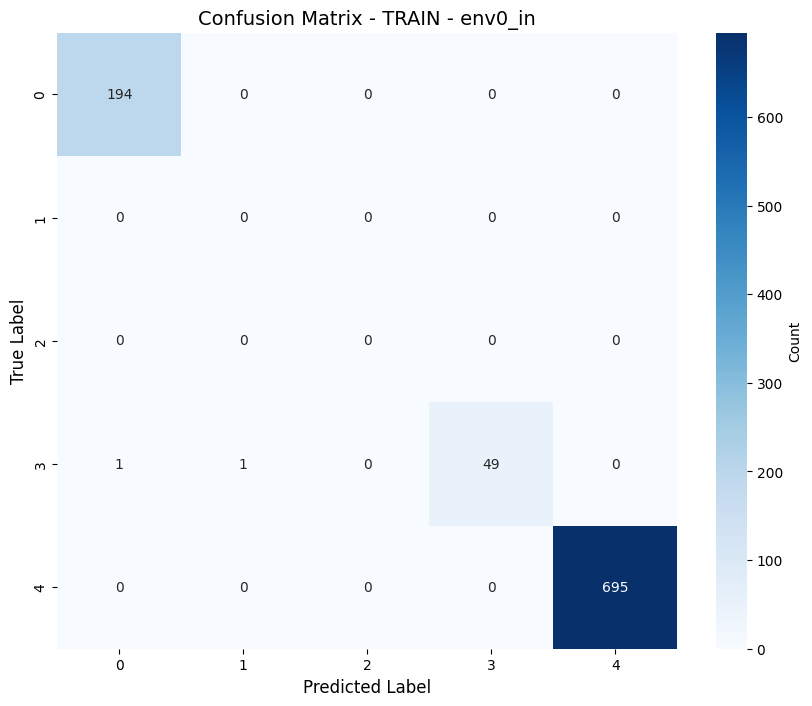


TRAIN - env1_in:
  Loss: 0.1563
  Accuracy: 0.6593, Precision: 0.6952, Recall: 0.6593, F1: 0.6727
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env1_in.png


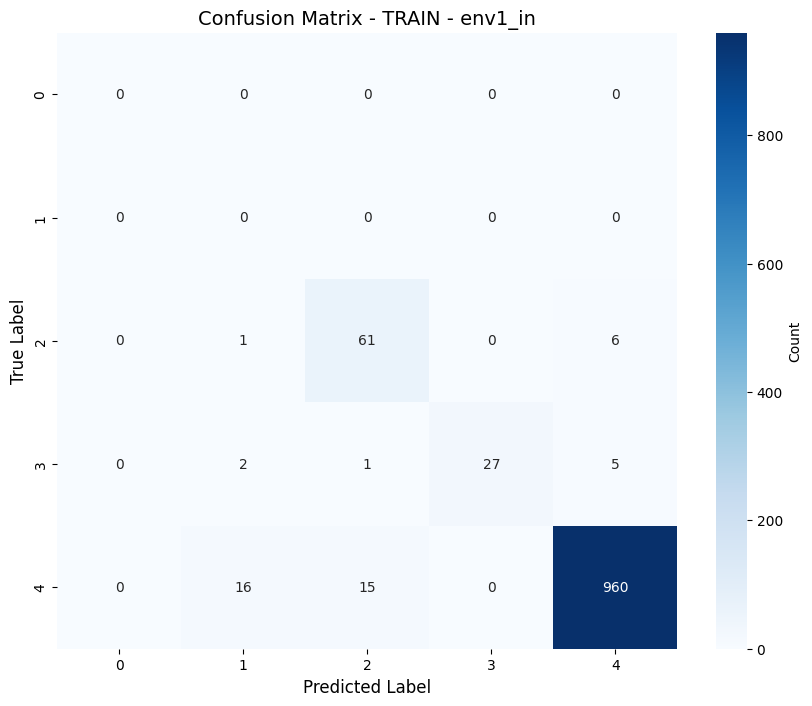


TRAIN - env2_in:
  Loss: 0.0882
  Accuracy: 0.7085, Precision: 0.7452, Recall: 0.7085, F1: 0.7258
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TRAIN_env2_in.png


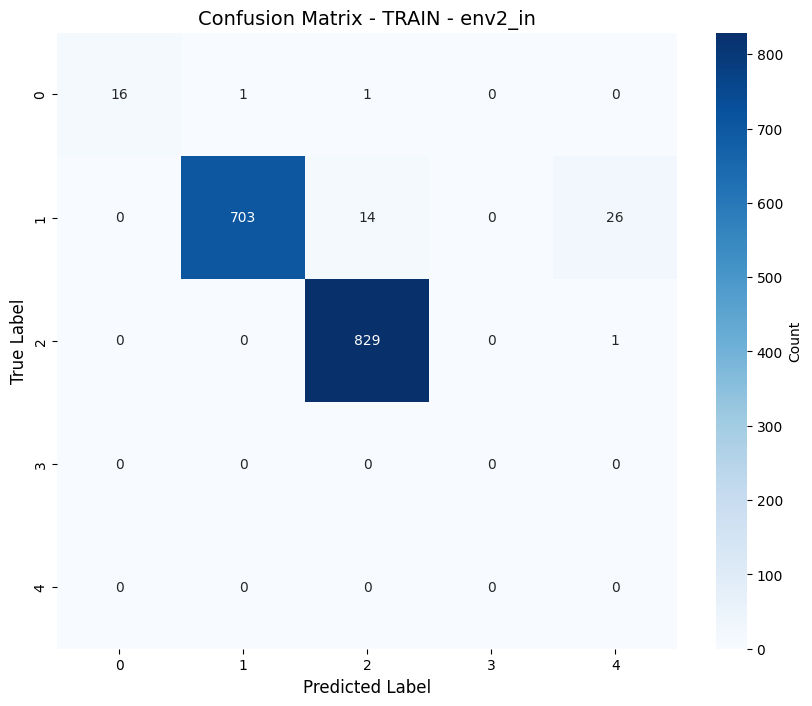


TEST - env3_in:
  Loss: 5.2201
  Accuracy: 0.5062, Precision: 0.5636, Recall: 0.5062, F1: 0.4264
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TEST_env3_in.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_TEST_env3_in.png


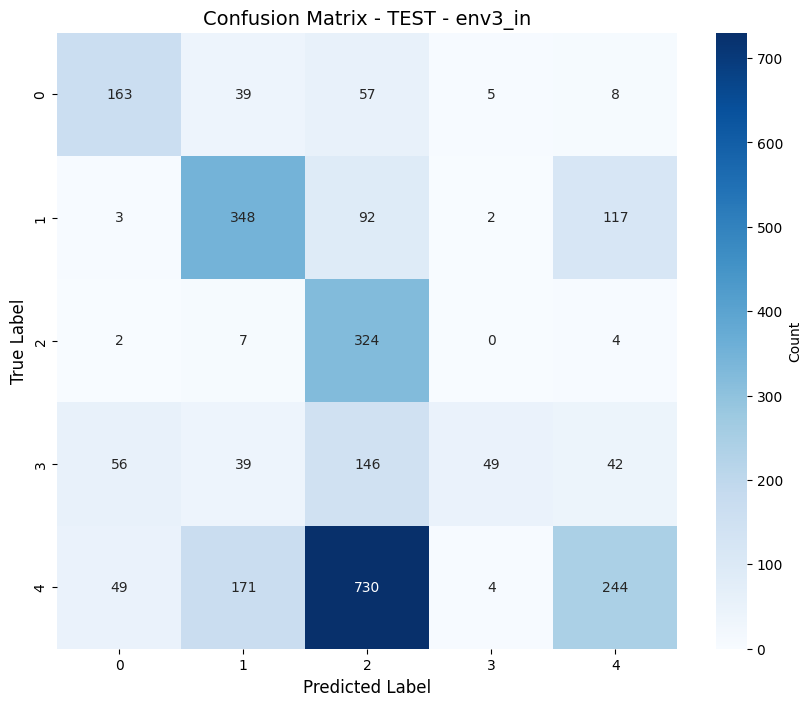


VAL - env0_out:
  Loss: 0.0016
  Accuracy: 0.7286, Precision: 0.7442, Recall: 0.7286, F1: 0.7361
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env0_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env0_out.png


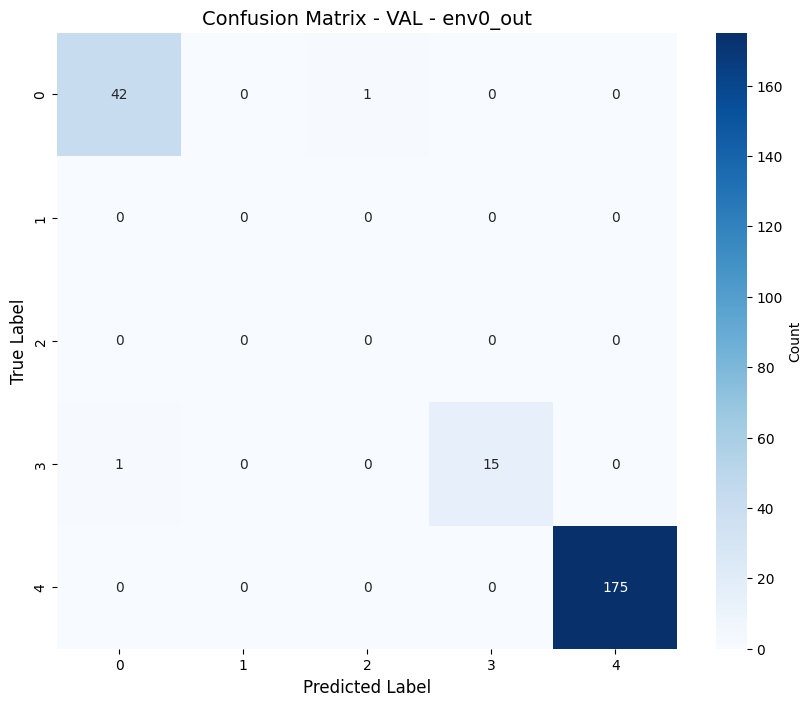


VAL - env1_out:
  Loss: 1.1210
  Accuracy: 0.3119, Precision: 0.3918, Recall: 0.3119, F1: 0.3412
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env1_out.png


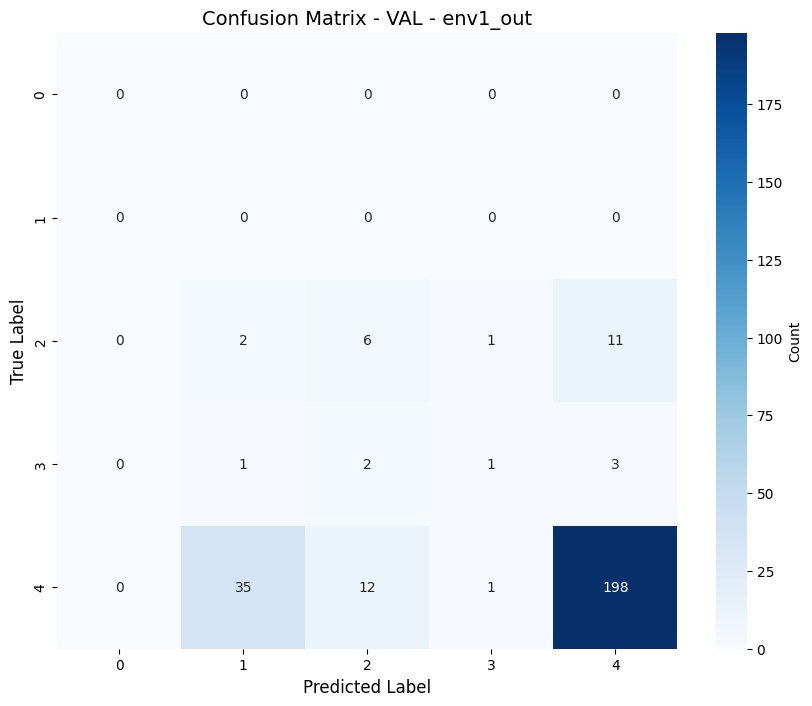


VAL - env2_out:
  Loss: 0.6157
  Accuracy: 0.5422, Precision: 0.5513, Recall: 0.5422, F1: 0.5364
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_VAL_env2_out.png


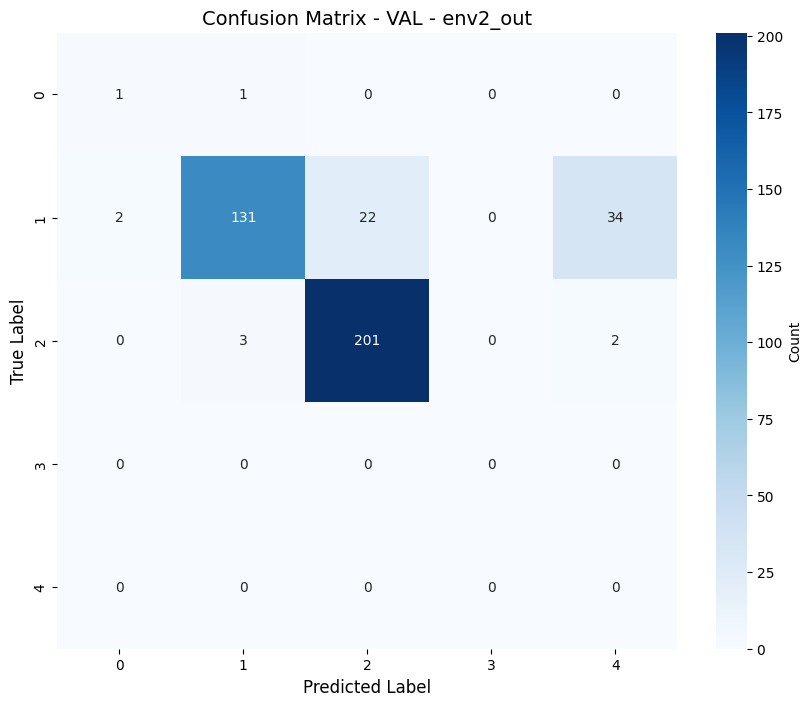


OTHER - env3_out:
  Loss: 5.0507
  Accuracy: 0.4760, Precision: 0.5147, Recall: 0.4760, F1: 0.3878
  Saved CSV to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_OTHER_env3_out.csv
  Saved plot to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/confusion_matrix_OTHER_env3_out.png


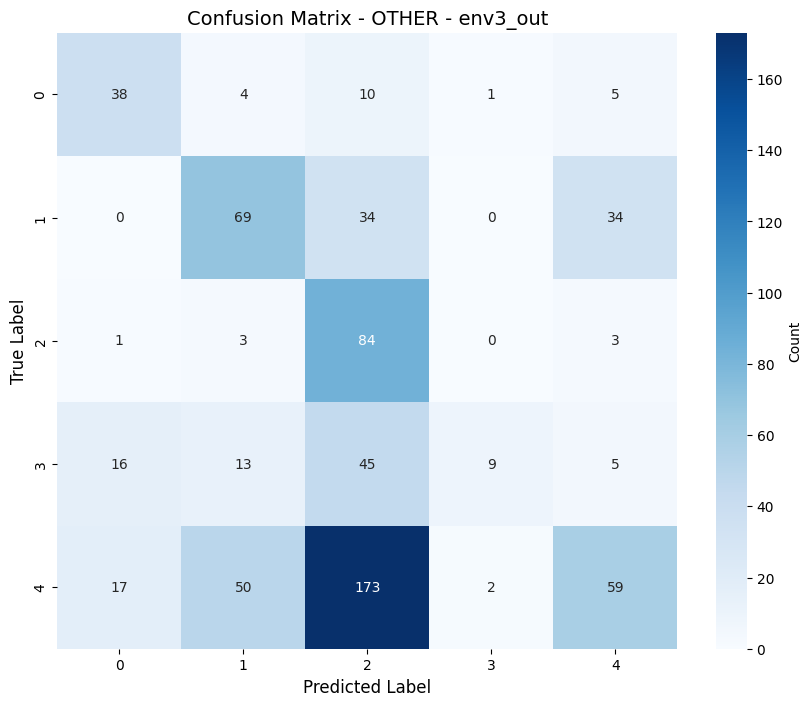


Training curves saved to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/training_curves_VLCS.png


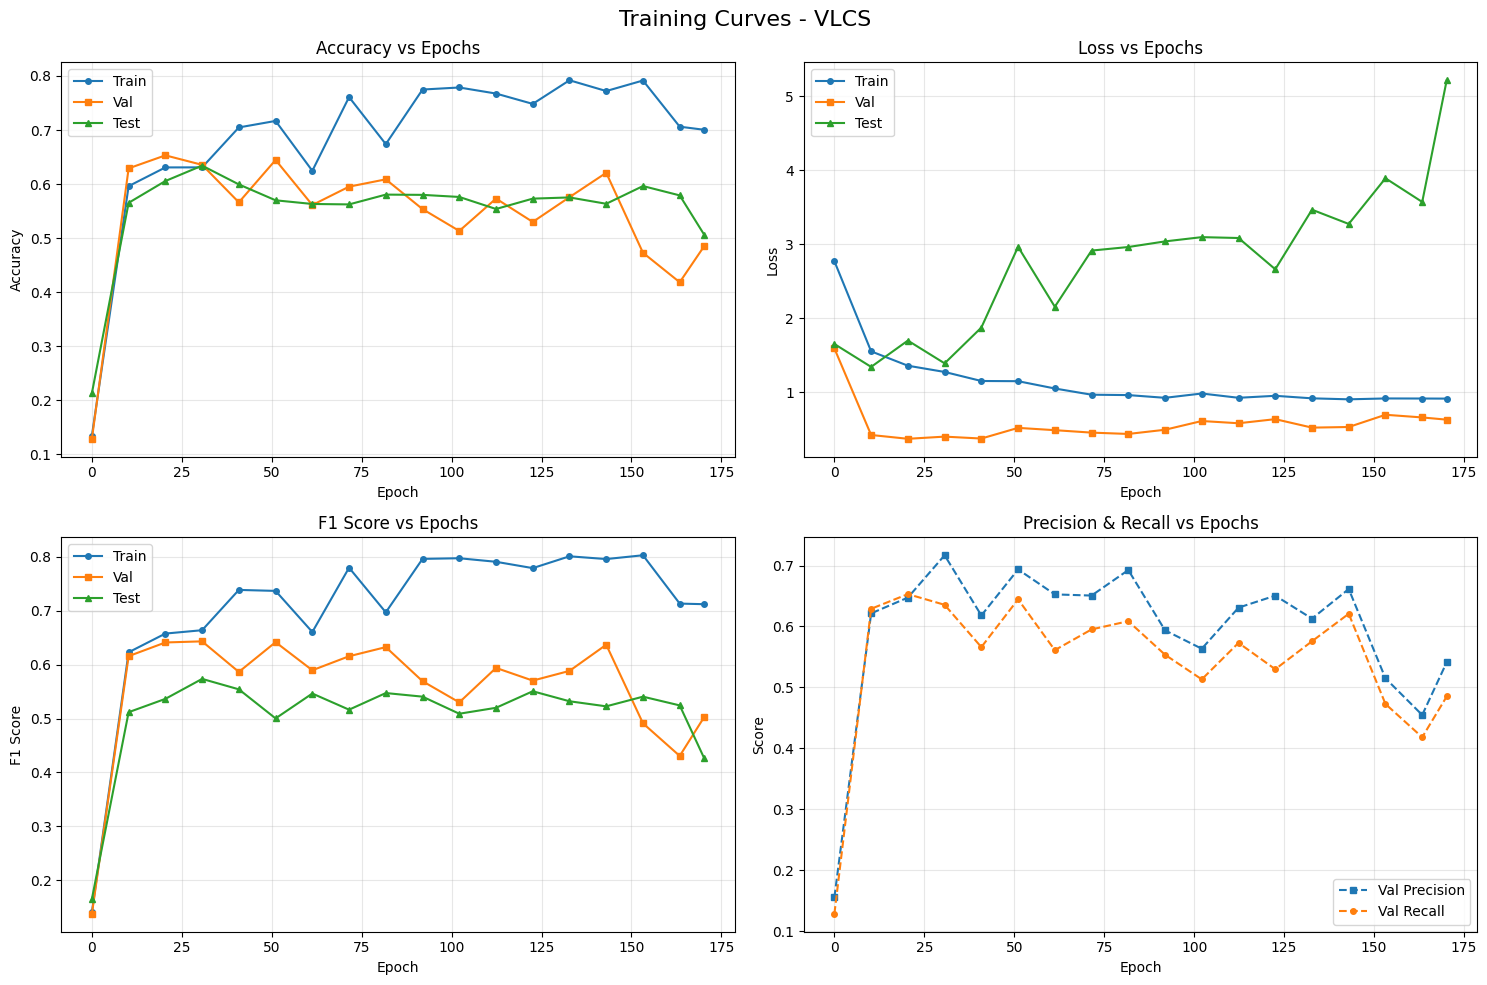

Epoch time plot saved to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs/epoch_times_VLCS.png


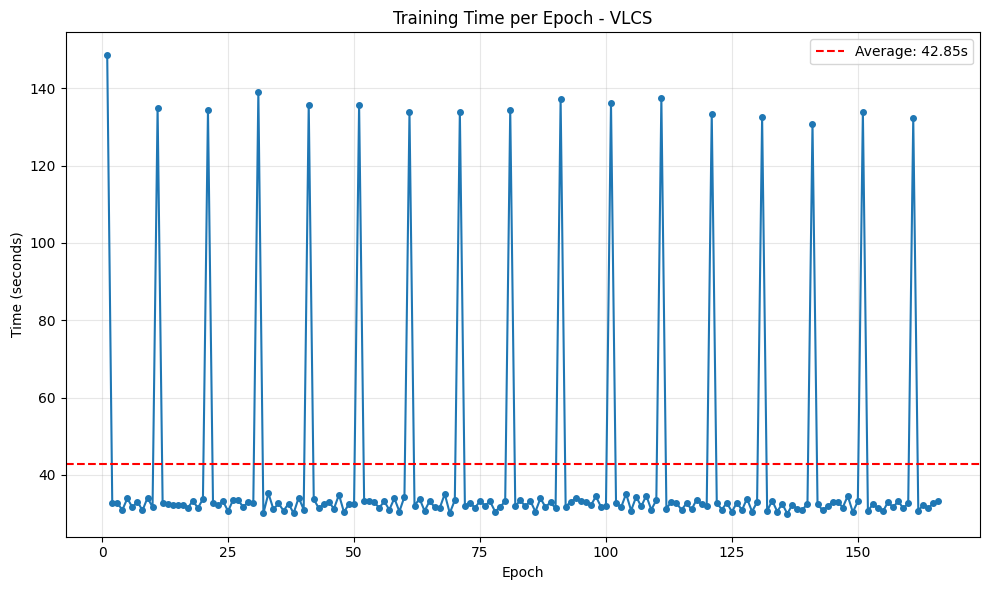


All results saved to: /kaggle/working/fond_dada_lodo_vlcs/test_3_VOC2007/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_VLCS.png
  - epoch_times_VLCS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)
Held out VOC2007 (ID 3)
Source domains: Caltech101; LabelMe; SUN09
Selected checkpoint: 2
Validation accuracy: 0.6531
Held-out test accuracy: 0.6056
Saved per-domain results to: /kaggle/working/fond_dada_lodo_vlcs/point7_lodo_per_domain_results.csv


{'dataset': 'VLCS',
 'held_out_domain_id': 3,
 'held_out_domain': 'VOC2007',
 'source_domains': 'Caltech101; LabelMe; SUN09',
 'selected_checkpoint_index': 2,
 'validation_accuracy_at_selected_checkpoint': 0.6530887683232626,
 'held_out_test_accuracy_at_selected_checkpoint': 0.6055755615234375}

In [35]:
run_lodo_domain(3, "VOC2007")


In [37]:
from pathlib import Path
import shutil

zip_base = Path("/kaggle/working") /f"{OUTPUT_ROOT.name}_VOC2007"
zip_path = Path(shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUTPUT_ROOT.parent,
    base_dir=OUTPUT_ROOT.name,
))
print(f"Updated full output archive: {zip_path}")


Updated full output archive: /kaggle/working/fond_dada_lodo_vlcs_VOC2007.zip


# FOND+DADA result summary

In [39]:
import pandas as pd
summary_path = OUTPUT_ROOT / "point7_lodo_per_domain_results.csv"
if summary_path.exists():
    results_df = pd.read_csv(summary_path)
    display(results_df)
    print("Mean held-out accuracy:", results_df["held_out_test_accuracy_at_selected_checkpoint"].mean())
else:
    print("No FOND+DADA domain runs have been completed yet.")


,dataset,held_out_domain_id,held_out_domain,source_domains,selected_checkpoint_index,validation_accuracy_at_selected_checkpoint,held_out_test_accuracy_at_selected_checkpoint
0,VLCS,1,LabelMe,Caltech101; SUN09; VOC2007,3,0.702072,0.356071
1,VLCS,2,SUN09,Caltech101; LabelMe; VOC2007,5,0.681276,0.516231
2,VLCS,3,VOC2007,Caltech101; LabelMe; SUN09,2,0.653089,0.605576


Mean held-out accuracy: 0.4926259120305379
